# 1 Загрузка данных

In [2]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import re
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from collections import Counter
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression

warnings.simplefilter('ignore')

In [3]:
# Импортируем датасет

df = pd.read_csv("C:\RStusio_files\skempi_v2.csv", sep = ';')

In [4]:
# Смотрим заголовки и типы данных в колонках

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   #Pdb                          7085 non-null   object 
 1   Mutation(s)_PDB               7085 non-null   object 
 2   Mutation(s)_cleaned           7085 non-null   object 
 3   iMutation_Location(s)         7085 non-null   object 
 4   Hold_out_type                 3311 non-null   object 
 5   Hold_out_proteins             7085 non-null   object 
 6   Affinity_mut (M)              7085 non-null   object 
 7   Affinity_mut_parsed           6800 non-null   float64
 8   Affinity_wt (M)               7085 non-null   object 
 9   Affinity_wt_parsed            7083 non-null   float64
 10  Reference                     7085 non-null   object 
 11  Protein 1                     7085 non-null   object 
 12  Protein 2                     7085 non-null   object 
 13  Tem

# 2 Концепция решения задачи

## 2.1 Немного о формулах

Итак, мы столкнулись м необходимостью расчета **ΔΔG** в рамках имеющихся у нас данных. Чтобы не «растекаться мыслию по древу» есть смысл поискать разъяснения в первоисточнике, т.е. статье составителя датасета SKEMPI 2.0 (URL: https://academic.oup.com/bioinformatics/article/35/3/462/5055583?login=false).

Автор статьи указывает нам формулу расчёта:
- (1) ***ΔG** = ΔH - TΔS = RTln(KD), где KD = 1/Ka = k_off/k_on*

Также найдём формулу расчёта искомого нами **ΔΔG** на сайте Ontosight (URL: https://ontosight.ai/glossary/term/Calculations-Of-Deltadeltag---cycl).
- (2) ***ΔΔG** = ΔG2 - ΔG1* (что вполне логично, но лишний раз убедиться не будет лишним)

## 2.2 Представление о данных
(Далее идут рассуждения меня, т.е. человека выполняющего тестовое задание)

В поисках дополнительной информации я обратился к статье *Khan Muhammad Tahir «Gibbs Free Energy Calculation of Mutation in PncA and RpsA Associated With Pyrazinamide Resistance» DOI:10.3389/fmolb.2020.00052 (URL: https://www.frontiersin.org/journals/molecular-biosciences/articles/10.3389/fmolb.2020.00052/full).*

Автор в своих исследованиях использует метод сравнения свободной энергии Гиббса дикого (WT) и мутантного (MTs) типов. 

Разбирая формулу (1) установим некоторые соотвествия колонкам датасета элементам формулы. Исходя из статьи, делавем вывод, что:
1) **KD = Affinity_mut_parsed** (для мутаций) или **Affinity_wt_parsed** (для диких) т.к. это указано автором статьи непосредственно ["...the wild-type and mutant affinities (KD, M),..."]. *Также обратим внимание, что колонки Affinity_mut_(M) и Affinity_mut_parsed одинаковы, за исключением текстового формата данных и научной записи числа у первой.* Текстовый формат данных, в нашем случае, непригоден для анализа информация, так что это дает нам право **исключить из датасета колонки Affinity_mut_(M) и Affinity_wt_(M)**.
2) **R ≈ 1.987** так как посмотрев в интернете мы увидим, что R является универсальной газовой константой и её значени равно 8.3144Дж(моль/К). Подобный формат нам не совсем подходит, логичнее всего будет перевести данную константу в калории и, соответсвенно, получим R = 1.987кал(моль/К).
3) **T = Temperature** (что вполне логично).

Теперь разберем формулу (2) по схожему принипу:
1) **ΔG2 = RTln(KD_mut), где KD_mut = Affinity_mut_parsed** (мутации), т.к. в контексте белок-белковых взаимодействий мы хотим понять, в как мутация повляла на связывание. Логично будет, соответсвенно, от энергии мутировавшего белка отнять энергию дикого. Положительные результаты будут говорить о низком уровне связывания за счет роста константы диссоциации KD, что с высокой вероятностью вызовет нестабильность данного соединения. Соовтветсвенно рассуждаем и про отрицательный знак.
2) **ΔG1 = RTln(KD_wt), где KD_wt = Affinity_wd_parsed** (объяснили выше).

И, наконец, выведем конечную формулу вида:
- (3) **ΔΔG** = RTln(KD_mut) - RTln(KD_wd) => **ΔΔG = RTln(KD_mut/KD_wd)** по свойству вычитания логарифмов.

# 3 Работа с данными

## 3.1 Очистка и подготовка данных

In [16]:
# Переведём значения колонки Tempertaure в числовой формат и заодно посчитаем NaN

df['Temperature'] = pd.to_numeric(df['Temperature'], errors = 'coerce')
df['Temperature'].isnull().sum()

2355

**Уалять или не удалять?**

Здесь уже встаёт вопрос о том, что же делать: заменить NaN на какие-либо другие значения или вообще исключить? На мой взгляд, удаление 2355 значений будет достаточно весомым, т.к. они составляют **33.24% от всех данных**. Возможно, это решение будет фатальным для работы, но я бы хотел заменить NaN на универсальное значение температуры равное 298 К.

In [18]:
# Присваиваем 0 и NaN значение в 298 и проверяем

df['Temperature'] = df['Temperature'].replace(0, 298.00).fillna(298)
df['Temperature'].isnull().sum()

0

In [19]:
# Смотрим информацию о количестве записей в датасете

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   #Pdb                          7085 non-null   object 
 1   Mutation(s)_PDB               7085 non-null   object 
 2   Mutation(s)_cleaned           7085 non-null   object 
 3   iMutation_Location(s)         7085 non-null   object 
 4   Hold_out_type                 3311 non-null   object 
 5   Hold_out_proteins             7085 non-null   object 
 6   Affinity_mut (M)              7085 non-null   object 
 7   Affinity_mut_parsed           6800 non-null   float64
 8   Affinity_wt (M)               7085 non-null   object 
 9   Affinity_wt_parsed            7083 non-null   float64
 10  Reference                     7085 non-null   object 
 11  Protein 1                     7085 non-null   object 
 12  Protein 2                     7085 non-null   object 
 13  Tem

**Уалять или не удалять?**

Если мы посмотрим на состав данных всего датасета, то заметим, что значения **Affinity_wt_parsed = 7083** и **Affinity_mut_parsed = 6800**. В данном случае мы не можем заменить ни на какое значения, что вынуждает нас удалить отсутсвующие значения.

Заодно избавимся от «избыточных» колонок **Affinity_mut (M)** и **Affinity_wt (M)**, т.к. они повторяют информацию своих «двойников». А также от колонок **22, 23, 23 и 25**, т.к. записей в них слишком мало, чтобы играть роль решающих признаков. Также, на мой взгляд, можно удалить колонки 14-20, т.к. они сосотавляют около 27% от общего числа данных и в нашем кейсе построения «простой» модели будут немного избыточны, т.к. некоторая информация из этих колонок уже косвенно «вшита» в **Affinity_wt_parsed, Affinity_mut_parsed и ddG**. Под удаление также попадают колонки **Hold_out_type** и **Hold_out_proteins** так как также не несут особо важной информации. + SCEMPI

In [21]:
# Удаляем значения, содержащие 0 или NaN в обеих колонках и проверяем

df = df.dropna(subset=['Affinity_wt_parsed' , 'Affinity_mut_parsed'])
df['Affinity_wt_parsed'].isnull().sum()

0

In [22]:
# Проверяем Affinity_mut_parsed на 0

df['Affinity_mut_parsed'].isnull().sum()

# Избавляемся от лишних колонок

columns_to_drop = [
    'Affinity_mut (M)', 'Affinity_wt (M)',
    'dH_mut (kcal mol^(-1))', 'dH_wt (kcal mol^(-1))',
    'dS_mut (cal mol^(-1) K^(-1))', 'dS_wt (cal mol^(-1) K^(-1))',
    'kon_mut (M^(-1)s^(-1))', 'kon_mut_parsed ', 'kon_wt (M^(-1)s^(-1))',
    'kon_wt_parsed', 'koff_mut (s^(-1))', 'koff_mut_parsed', 'koff_wt (s^(-1))',
    'koff_wt (s^(-1))', 'kon_mut_parsed', 'koff_wt_parsed', 'Hold_out_type', 'Hold_out_proteins',
    'SKEMPI version', 'Notes', 'Reference'
]

df = df.drop(columns = columns_to_drop, errors='ignore')

In [23]:
# Напишем функцию вычисления ΔΔG

def calculate_ddg(row):
    R = 1.987  #Та самая постоянная
    
    KD_mut = row['Affinity_mut_parsed']  # Мутантная KD_mut
    KD_wt = row['Affinity_wt_parsed']    # Дикая KD_wt

    T = row['Temperature']
    
    # Рассчитываем ΔΔG и переводим в ккал/моль
    ddg = R * T * np.log(KD_mut / KD_wt) / 1000
    
    return ddg

In [24]:
# Добавим соответсвующую вычисленную колонку

df['ddG'] = df.apply(calculate_ddg, axis = 1)

## 3.2 Feature selection

In [26]:
df = df.drop(columns=['#Pdb', 'Mutation(s)_PDB', 'Protein 1', 'Protein 2'])

### 3.2.1 Колонка iMutation_Location(s)

Для перевода знаечний данной колонки из категориальных в числовые есть смысл посмотреть со сколькими уникальными значениями мы имеем дело. Вызвав метод **.unique()** мы узнали, что имеем всего 5 возможных вариантов: **COR, SUP, RIM, SUR и INT**. Из названи колонки итак понятно, что эти сокращения говорят о локализации мутаций, однако как они переводятся? Автор статьи, *в разделе «2.3 Post-processing and annotation»*, некоторым значениям даёт вполне развёрнутое описание. Отсюда мы узнаём, что *по Levy (2010)*:


<u>Мутации на interface (наверное, можно перевечти как «на границе взаимодействия»):</u>
- COR (от слова CORE) - локализация в основном открытых растворителю в несвязанном состоянии областях, но зарытые при связывании;
- SUP (от слова SUPPORT) - локализация в основном зарытых в несвязанном состоянии областях и полностью зарытых при связывании;
- RIM (от слова RIM) - локализация в частично закрытых при связывании областях.


<u>Мутации, находящиеся далеко от связывающего сайта:</u>
- SUR (от слова SURFACE) - локализация где-то на поверхности белка (и скорее всего не учавствующая в связывании);
- INT (от слова INTERIOR) - локализация во внутренних областях.

Исходя также из факта, что в одной ячейке, может быть несколько локализаций: ['SUR,INT,INT,SUR,RIM,RIM,SUP,RIM,RIM'], я принял решение о кодировании признаков **методом подсчета частот** встречаемых в разных белках.

In [29]:
#  Смотрим уникальные значения по колонке «iMutation_Location(s)»

unique_values = df['iMutation_Location(s)'].unique()
print(unique_values)

['COR' 'INT' 'SUP' 'SUP,INT' 'COR,COR' 'RIM' 'SUR' 'COR,RIM' 'COR,SUR'
 'SUP,RIM' 'SUP,COR' 'SUP,SUR' 'COR,RIM,RIM' 'SUR,COR,RIM,COR,RIM,RIM,INT'
 'SUR,RIM' 'RIM,SUP' 'SUP,SUP,COR' 'COR,COR,INT' 'SUR,SUP' 'RIM,COR'
 'RIM,RIM' 'SUP,COR,RIM' 'COR,RIM,SUR' 'COR,RIM,INT,SUR' 'COR,SUP'
 'SUR,INT,SUR,INT,RIM,SUR,COR,RIM,RIM,SUR,SUP,COR,RIM,INT,SUR,INT,COR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,INT,SUR'
 'SUR,INT,INT,SUR,RIM,RIM,SUP,RIM,RIM,SUR,SUP,COR,RIM,INT,SUR,INT,RIM,SUR,SUR,SUR,INT,SUR,SUR,SUR,INT,INT,SUR'
 'SUR,SUP,COR,RIM,INT,SUR,INT,COR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,INT,SUR'
 'SUR,INT,INT,SUR,RIM,RIM,SUP,RIM,RIM'
 'SUR,INT,SUR,INT,RIM,SUR,COR,RIM,RIM,SUR,SUR,SUR,INT,SUR'
 'SUR,SUP,COR,RIM,INT,SUR,INT,RIM,SUR,SUR,SUR,INT,SUR'
 'SUR,INT,SUR,INT,RIM,SUR,COR,RIM,RIM,COR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,INT,SUR'
 'SUR,SUP,COR,RIM,INT,SUR,INT'
 'SUR,INT,SUR,INT,RIM,COR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,SUR,INT,SUR'
 'RIM,SUP,RIM,RIM,SUR,SUP,COR,RIM,INT,SUR,INT'
 'SUR,INT,COR,SUR,SUR,SUR,SUR,SUR,SUR,SU

In [30]:
# Переводим признаки в бинарные

locations = ['COR', 'SUP', 'RIM', 'INT', 'SUR']

for loc in locations:
    df[f'count_{loc}'] = df['iMutation_Location(s)'].str.count(loc)

# И заодно удаляем изначальную колонку

df = df.drop(columns=['iMutation_Location(s)'])

In [31]:
# От греха подальше смотрим даатсет. Убеждаемся в том, что нужные нам колонки появились

print(df)

     Mutation(s)_cleaned  Affinity_mut_parsed  Affinity_wt_parsed  \
0                  LI38G         5.260000e-11        1.120000e-12   
1                  LI38S         8.330000e-12        1.120000e-12   
2                  LI38P         1.020000e-07        1.120000e-12   
3                  LI38I         1.720000e-10        1.120000e-12   
4                  LI38D         1.920000e-09        1.120000e-12   
...                  ...                  ...                 ...   
7080                KP8R         2.400000e-04        5.500000e-06   
7081               TP11A         1.100000e-03        5.500000e-06   
7082               TP11S         3.380000e-05        5.500000e-06   
7083               TP11N         4.340000e-05        5.500000e-06   
7084          YP6F,TP11S         4.290000e-05        5.500000e-06   

      Temperature Method       ddG  count_COR  count_SUP  count_RIM  \
0           294.0   IASP  2.248727          1          0          0   
1           294.0   IASP  1.1

### 3.2.2 Колонка Method

Учитывая всё то множество использованных в датасете методов, которое мы можем увидеть также вызвав метод **.unique()**, есть смысл **разделить их на «родственные группы»** исходя со статьёй автора. 

В своей статье автор не даёт расшифровку (т.е. полное название аббревиатур), а ссылается на статью другого автора: *«Geng C. et al. (2016) Exploring the interplay between experimental methods and the performance of predictors of binding affinity change upon mutations in protein complexes. (DOI: 10.1093/protein/gzw020)»*. Так как некоторые методы **очень тяжело найти в Интернете просто вбив аббревиатуру,** привожу описание методов ниже по *«Geng C. et al.(2016) Exploring [...] complexes. DOI: 10.1093/protein/gzw020»*. (с разбивкой по «родственным группам»):


1) <u>Методы SPR (поверхностный плазмонный резонанс):</u>
- SPR (Surface plasmon resonance);
- CSPRIA (Competition solid-phase radio-immune assay).

2) <u>Методы флуоресценции:</u>
- FL (Fluorescence);
- SFFL (Stopped-flow fluorescence);
- IAFL (Inhibition assay fluorescence).

3) <u>Другие методы:</u>
- IASP (Inhibition assay spectroscopy);
- ITC (Isothermal titration calorimetry);
- RA (Radioactivity);
- IAGE (Inhibition assay gel electrophoresis);
- IARA (Inhibition assay radioactivity);
- EMSA (Electrophoretic mobility shift assay);
- ELISA (Enzyme-linked immunosorbent assay);
- ELFA (Enzyme-linked functional assay);
- SP (Spectroscopy);
- KinExA (Kinetic exclusion assay).

**Отдельное внимание:**
- **SFPF (метод не представлен ни автором статьи (DOI: 10.1093/protein/gzw020), ни автором датасета;**
- **SE (метод не представлен ни автором статьи (DOI: 10.1093/protein/gzw020), ни автором датасета. Есть предположение, что это SEC (Size Exclusion Chromatography);**
- **BI (метод не представлен ни автором статьи (DOI: 10.1093/protein/gzw020), ни автором датасета. Есть предположение, что это BI (Biological Indicator);**
- **ESMA (метод не представлен ни автором статьи (DOI: 10.1093/protein/gzw020), ни автором датасета.**

In [35]:
# Смотрим уникальные значения для колонки Method

unique_values = df['Method'].unique()
print(unique_values)

['IASP' 'SFFL' 'SPR' 'ITC' 'IAFL' 'SE' 'FL' 'RA' 'CSPRIA' 'IAGE' 'IARA'
 'SPR,SFFL' 'EMSA' 'ELISA' 'SFPF' 'ELFA' 'SP' 'BI' 'KinExA' 'ESMA']


In [36]:
# Реализуем функцию по разбиению методов исследования на родственные группы

def process_methods(df):
    
    # Есть смысл сначала поколдовать над копией датасета, а уже потом имплементировать изменения в исходный
    df_processed = df.copy()
    
    # Зададим определения родственным группам
    method_groups = {
        'SPR_group': ['SPR', 'CSPRIA'],
        'Fluorescence': ['FL', 'SFPF', 'IAFL'],
        'Other_methods': ['SE', 'RA', 'ITC', 'IAGE', 'IARA', 'EMSA', 'ELISA', 'ELFA', 'SP', 'BI', 'KinExA', 'ESMA', 'IASP', 'SFFL']
    }
    
    # Инициализируем все новые колонки нулями
    for group in method_groups:
        df_processed[group] = 0
    
    # Обрабатываем каждую строку через метод .iterrows()
    for idx, row in df.iterrows():
        methods = str(row['Method']).split(',')

        # Проходимся циклом по элементам, чтобы избавиться от возможных пробелов
        for method in methods:
            method = method.strip()
            found = False
            
            # Проверяем каждую группу
            for group, group_methods in method_groups.items():
                if method in group_methods:
                    df_processed.at[idx, group] = 1
                    found = True
                    break
            
            # Если метод ВДРУГ не найден в основных группах или я забыл указать, помечаем как Other
            if not found:
                df_processed.at[idx, 'Other_methods'] = 1
    
    return df_processed

# Применяем функцию к основному датасету

df = process_methods(df)

In [37]:
# Удаляем уже не нужную колонку Method

df = df.drop(columns=['Method'])

# Заодно смотрим, применились ли все необходимые изменения

print(df)

     Mutation(s)_cleaned  Affinity_mut_parsed  Affinity_wt_parsed  \
0                  LI38G         5.260000e-11        1.120000e-12   
1                  LI38S         8.330000e-12        1.120000e-12   
2                  LI38P         1.020000e-07        1.120000e-12   
3                  LI38I         1.720000e-10        1.120000e-12   
4                  LI38D         1.920000e-09        1.120000e-12   
...                  ...                  ...                 ...   
7080                KP8R         2.400000e-04        5.500000e-06   
7081               TP11A         1.100000e-03        5.500000e-06   
7082               TP11S         3.380000e-05        5.500000e-06   
7083               TP11N         4.340000e-05        5.500000e-06   
7084          YP6F,TP11S         4.290000e-05        5.500000e-06   

      Temperature       ddG  count_COR  count_SUP  count_RIM  count_INT  \
0           294.0  2.248727          1          0          0          0   
1           294.0  1.

### 3.2.3 Колонка Mutation(s)_cleaned

#### 3.2.3.1 Работаем с составными значениями данных

В ходе проведения проверки на уникальные значения с помощью метода **.unique**, я также наткнулся не на самые приятные примеры данных, которые я определил как явный выброс.

*Например: (464 строка) [QA15E, LA16F, TA18K, TA19K, NA22R, DA24E, TA25G, SA26A, SA27T, EA30D, LA31D, VA32N, TA36R, HA37E, EA40R, MA41L, SA46D, KA55R, EA56D, GA57D, DA58R, DA59E, SA63E, NA67K, TA68E, VA69I, QA71E]*

Подобные данные я назвал **«составными мутациями»**, т.к. в одном белке встречается мутаций **больше, чем 1**. Казалось бы, от подобных «гига-строк» явно нужно избавиться. Да, это так, но каков масштаб «бедствия»? Прежде всего стоит проверить абсолютно всю колонку на наличие составных мутаций через метод **.str.contains(',')** содержащий разделительный знак – запятую. Почему её? А мы поймём это, когда вызовем функцию **print(df)** или просто df (если работаете в Google Colab или Anaconda) и заметим, что строка 7084 как раз содержит составную мутацию. Посчитаем количество всех строк, содержащих запятую и посмотрим, что делать дальше – **удалять или нет?**

In [41]:
# Проверяем, содержит ли строка запятую (т.е. несколько мутаций)

df['is_multiple_mutation'] = df['Mutation(s)_cleaned'].str.contains(',')

# Считаем количество
multiple_count = df['is_multiple_mutation'].sum()
total_count = len(df)
percentage_multiple = (multiple_count / total_count) * 100

print(f"Составные мутации: {multiple_count} строк ({percentage_multiple:.1f}% данных)")

Составные мутации: 1842 строк (27.1% данных)


In [42]:
# Смотрим максимальное значение выброса или «гига-строку»

df["n_mutations"] = df["Mutation(s)_cleaned"].str.count(",") + 1  # Единицу прибавляем для того, чтобы зафиксировать одну мутацию
max_mutations_row = df.loc[df["n_mutations"].idxmax()]

# Выводим строку с максимальным значением мутаций

print(f"Максимум мутаций в строке {max_mutations_row.name}:")
print(max_mutations_row["Mutation(s)_cleaned"])

Максимум мутаций в строке 464:
QA15E,LA16F,TA18K,TA19K,NA22R,DA24E,TA25G,SA26A,SA27T,EA30D,LA31D,VA32N,TA36R,HA37E,EA40R,MA41L,SA46D,KA55R,EA56D,GA57D,DA58R,DA59E,SA63E,NA67K,TA68E,VA69I,QA71E


Как мы можем заметить **27.1% – слишком много для простого удаления**. В таком случае придётся искать иные методы работы с такими данными. 

**Первым этапом** самым логичным вариантом, в нашем случае, будет вызвать визуализацию данных колонки Mutation(s)_cleaned и посмотреть максимальные отклонения от часто встречаемых значений. Для этого вызовем два графика: обычную **столбчатуб гистограмму распределения**, т.к. на мой взгляд, она вполне удовлетворит наш интерес узнать: «А сколько вообще данных с каким числом мутаций у нас есть?». А также **boxplot**, который покажет нам более детально количество выбросов.

**Вторым этапом**, исходя из визуализации, выберем для себя некий **ориенир**, после которого все выбросы и составные мутации можно будет удалить (без угрызений совести).

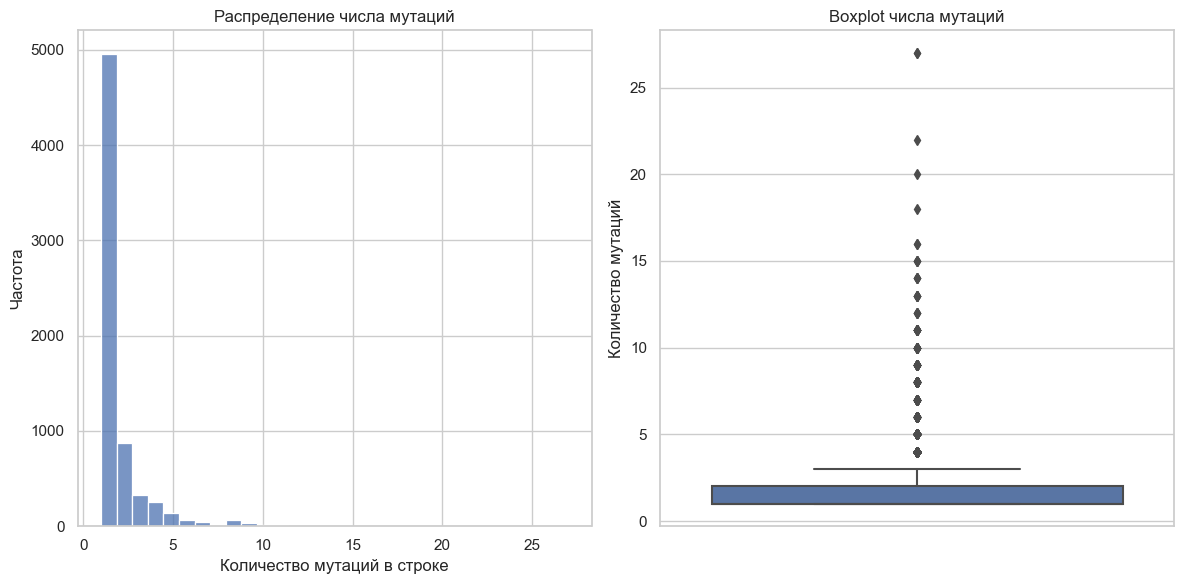

In [44]:
# Выводим графики

# Настраиваем стиль графиков
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Вызываем гистограмму распределения
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='n_mutations', bins=30)
plt.title('Распределение числа мутаций')
plt.xlabel('Количество мутаций в строке')
plt.ylabel('Частота')

# Вызываем Boxplot для выявления выбросов
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='n_mutations')
plt.title('Boxplot числа мутаций')
plt.ylabel('Количество мутаций')

plt.tight_layout()
plt.show()

In [45]:
# Вызываем подсчет строк с мутациями, больше 5

outliers_count = (df['n_mutations'] > 5).sum()
total_rows = len(df)
percentage_outliers = (outliers_count / total_rows) * 100

# Для удобства выводим на экран количество всех строк колонки и количество строк с мутациями, больше чем 5

print(f"Всего строк в датафрейме: {total_rows}")
print(f"Строк с >5 мутациями: {outliers_count} ({percentage_outliers:.2f}% от всех данных)")

Всего строк в датафрейме: 6798
Строк с >5 мутациями: 256 (3.77% от всех данных)


Как Вы уже могли заметить, я решил выбрать максимальное значения ориентира в **5 мутаций.** На мой взгляд, мы не много потеряем, т.к. всего таких «огромных» **строк 256, что составляет 3.77% от всех данных.** Это даёт нам право удалить их из наших данных.

In [47]:
# Сохраняем только те значения, что меньше или равны 5

df = df[df['n_mutations'] <= 5].copy()

# Проверяем изменения в количестве данных. Да, всё верно. 6798 - 256 = 6542

total_rows = len(df)
print(f"Всего строк в датафрейме: {total_rows}")

Всего строк в датафрейме: 6542


#### 3.2.3.2 Работаем с самими мутациями

На заключительном этапе по подготовке данных, непосредственно, к самому обучению, мы столкнулись с особенностью, что, возможно, абсолютно все значения колонки Mutation(s)_cleaned уникальны. Наш любимый метод **.unique()** выдаёт результат в формате многоточия «...» – это значит, что уникальных данных настолько много, что система сокращает этот объём данных в формате многоточия.

Из названия колонки итак понятно, что это кодирока мутации, каждый символ которой указывает на конкретное значение. Обратившись на сайт датасета SCEMPI 2.0 в раздел **«FAQ and Help»,** узнаем, какая именно номенклатура заложена в сокращение. Согласно ответу автора на вопрос: **«Q. What is the format of the database?»** (URL: https://life.bsc.es/pid/skempi2/info/faq_and_help) мы узнаём, что:
> «The mutation(s) corresponding to the residue numbering found in the protein databank. **The first character is the one letter amino acid code** for the original residue, **the second character is the chain identifier, the third to penultimate characters indicate the residue number,** followed by the residue insertion code where applicable, and **the final character indicates the mutant amino acid.** Where multiple mutations are present, they are separated by commas».

<u>Переводя на русский и подводя краткий итог, получаем вполне логическую схему (на примере мутации из третьей строки *LI38I*), где:</u>
- L – первая буква исходнй аминокислоты;
- I – идентификатор цепи;
- 38 – номер остатка;
- I – другая аминокислота после мутации.

Казалось бы, самая логичная прследовательность действий в данном случае – **закодировать аминокислоты через какие-то другие признаки,** например физико-химические. То есть, например, V (валин) будет представлен **гидрофобностью и молекулярной массой** (hyd: -1.3, molw: 117.15). Номер остатка имеет числовой формат, поэтому с ним ничего не делаем. Но как быть с идентификатором цепи?

После вызова метода **.unique()** мы заметим, что всего в уникальных значений: ['I', 'A', 'D', 'B', 'C', 'N', 'U', 'P', 'E', 'H', 'W', 'L', 'T', 'Y', 'Q', 'G', 'M', 'F'].


In [51]:
# Создаём функцию, которая будет парсить все строки с мутациями

def parse_multiple_mutations(mutation_str):
    if pd.isna(mutation_str):
        return []
    
    mutations = []
    for mut in mutation_str.split(','):
        mut = mut.strip()
        
        # Задаём регулярному выражению формат: original_amino_acid + chain + position + XXX + mutant_amino_acid
        match = re.match(r'^([A-Z])([A-Z])(\d+)([A-Z]?)([A-Z])$', mut)
        if match:
            orig_aa, chain, pos, ins_code, mut_aa = match.groups()
            mutations.append({
                'orig_aa': orig_aa,
                'chain': chain,
                'pos': int(pos),
                'mut_aa': mut_aa
            })
    return mutations

Прошу не обращать пристального внимания на элемент регулярного выражения «XXX». Это вспомогательный элемент, без которого, к сожалению, была бы ошибка.

In [53]:
# Создаем список для расширенных данных

expanded_data = []

# Обрабатываем каждую строку
for _, row in df.iterrows():
    mutations = parse_multiple_mutations(row['Mutation(s)_cleaned'])
    
    # Для каждой мутации создаем отдельную строку с копией остальных данных (пример выше)
    for mut in mutations:
        new_row = row.to_dict()
        new_row.update(mut)
        expanded_data.append(new_row)

# Вносим все изменения в исходный датафрейм
df = pd.DataFrame(expanded_data)

In [54]:
# Выводим уникальные значения идентификаторов цепи

unique_values = df['chain'].unique()
print(unique_values)

['I' 'A' 'D' 'B' 'C' 'N' 'U' 'P' 'E' 'H' 'W' 'L' 'T' 'Y' 'Q' 'G' 'M' 'F']


**Что делать с идентификатором цепи?**

Отлично, узнали сколько всего вариантов цепей может быть, но как быть с составными мутациями, которые мы решили сократить в предыдущем примере на ориентире в количестве не более 5-ти мутаций? В ходе размышлений, я принял (возможно, фатальное) решение разобрать составные мутации на отдельные и вывести их в отдельные ниже строки с копированием предыдущих данных. Покажу на примере (заранее извиняюсь за корявый пример, показываю схематично как работает):

**БЫЛО:**

| Мутация  | Температура** |
|:--------:|:--------:|
| LI38I,YP6F    | 258.00   |
| TW38I,TH6F,YT99A    | 260.00   |


**СТАЛО** (я пометил изменения подчёркиванием):

| Мутация***             | Температура** | **Цепь** |
|:-------------------:|:-----------:|:----:|
| L<u>**I**</u>38I,YP6F           | 258.00      | **I**    |
| LI38I,Y<u>**P**</u>6F           | 258.00      | **P**    |
| T<u>**W**</u>38I,TH6F,YT99A    | 260.00      | **W**   |
| TW38I,T<u>**H**</u>6F,YT99A    | 260.00      | **H**    |
| TW38I,TH6F,Y<u>**T**</u>99A    | 260.00      | **T**    |


**  Колонка «Температура» была добавлена для большей наглядности;

*** Пусть Вас не смущает колонка «Мутация», а именно то, что в ней повторяются данные - в конечном итоге от нее мы избавимся за ненадобностью. Главное, что мы вынесли в отдельную строку идентификатор цепи.

**Стоит обратить внимание на то, что после всех преобразований ожидаемо увеличение общего числа данных до 9369**

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9369 entries, 0 to 9368
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mutation(s)_cleaned   9369 non-null   object 
 1   Affinity_mut_parsed   9369 non-null   float64
 2   Affinity_wt_parsed    9369 non-null   float64
 3   Temperature           9369 non-null   float64
 4   ddG                   9369 non-null   float64
 5   count_COR             9369 non-null   int64  
 6   count_SUP             9369 non-null   int64  
 7   count_RIM             9369 non-null   int64  
 8   count_INT             9369 non-null   int64  
 9   count_SUR             9369 non-null   int64  
 10  SPR_group             9369 non-null   int64  
 11  Fluorescence          9369 non-null   int64  
 12  Other_methods         9369 non-null   int64  
 13  is_multiple_mutation  9369 non-null   bool   
 14  n_mutations           9369 non-null   int64  
 15  orig_aa              

#### 3.2.3.3 Статистические тесты

Итак, мы **получили искомую колонку с идентификаторами цепи и увеличение общего количества данных на 37.82%.** Но опять же возникает вполне логичный вопрос: «А стоило ли проделывать все эти действия? Не проще ли было просто избавиться от этой колонки?»

Для ответа на этот вопрос стоит провести определённые статистические тесты. Первым делом, на мой взгляд, можно проверить данные на нормальность распределения через **тест Шапиро-Уилка и аналогичный тест Андерсона-Дарлинга.**

**Стоит обратить внимание на то, что тест Шапиро-Уилка, в нашем случае не будет работать со значениями меньше 3, а такие значения у нас как раз есть: N и Q. Поэтому в теле функции зададим проверку на валидное количество данных.**

**Тест Андерсона-Дарлинга также не будет работать при значениях меньше 50**

Проверка нормальности распределений:
   chain  n_obs       p_value     normal
1      A   2360  3.477208e-36      False
3      B   2239  1.752929e-14      False
0      I   1700  2.351080e-23      False
4      C    606  3.967023e-18      False
2      D    555  9.900986e-16      False
9      H    530  6.175171e-12      False
11     L    424  9.813184e-12      False
6      U    322  7.869382e-25      False
8      E    247  4.109430e-06      False
13     Y    113  3.932645e-07      False
7      P     93  9.929846e-11      False
12     T     80  5.779356e-08      False
15     G     54  8.437881e-05      False
10     W     26  2.914912e-05      False
16     M     11  4.860209e-03      False
17     F      5  1.495697e-01       True
5      N      2           NaN  Too small
14     Q      2           NaN  Too small


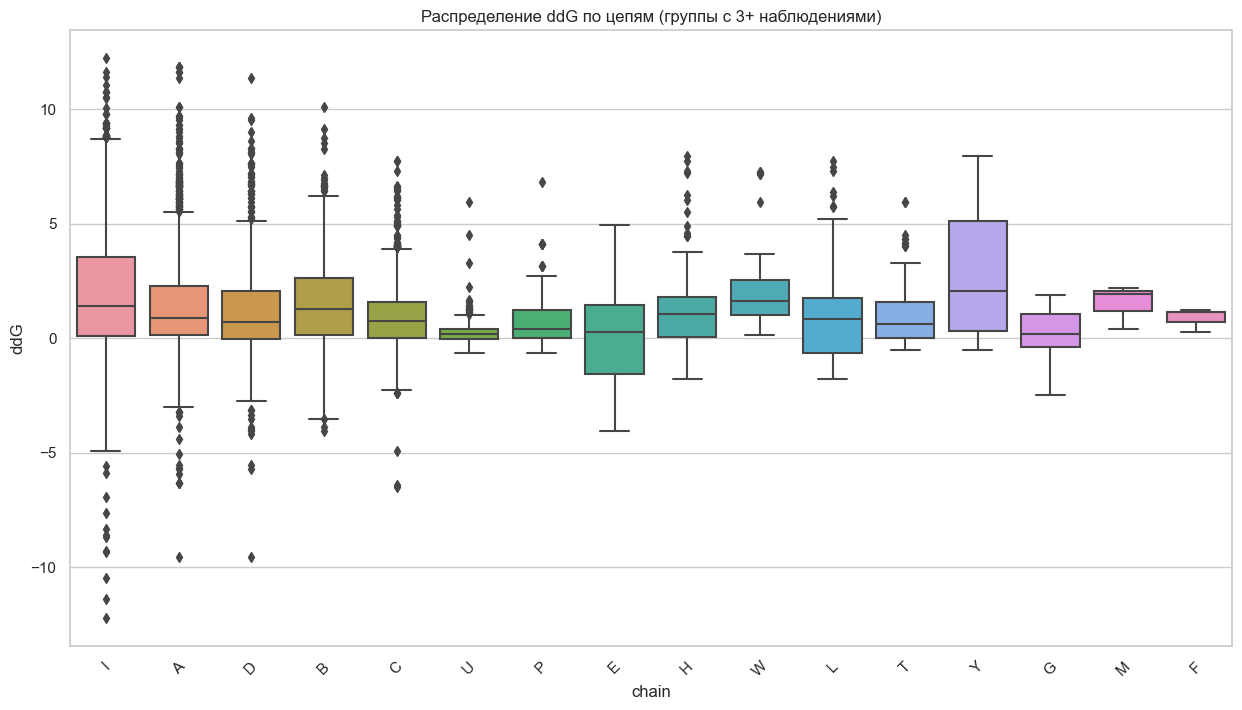


Тест Андерсона-Дарлинга (более устойчив для n>50):
Цепь I (n=1700): статистика=29.94, критические значения=[0.575 0.654 0.785 0.916 1.089]
Нормальность: отвергается

Цепь A (n=2360): статистика=63.41, критические значения=[0.575 0.655 0.786 0.916 1.09 ]
Нормальность: отвергается

Цепь D (n=555): статистика=15.81, критические значения=[0.572 0.651 0.781 0.912 1.084]
Нормальность: отвергается

Цепь B (n=2239): статистика=10.29, критические значения=[0.575 0.655 0.786 0.916 1.09 ]
Нормальность: отвергается

Цепь C (n=606): статистика=16.77, критические значения=[0.572 0.652 0.782 0.912 1.085]
Нормальность: отвергается

Цепь U (n=322): статистика=19.12, критические значения=[0.569 0.648 0.778 0.907 1.079]
Нормальность: отвергается

Цепь P (n=93): статистика=6.96, критические значения=[0.554 0.631 0.757 0.883 1.05 ]
Нормальность: отвергается

Цепь E (n=247): статистика=2.82, критические значения=[0.567 0.646 0.775 0.904 1.075]
Нормальность: отвергается

Цепь H (n=530): статистика=3.24, кри

In [59]:
# 1. Проверка нормальности с фильтрацией малых групп
normality_results = []
for chain in df['chain'].unique():
    data = df[df['chain'] == chain]['ddG'].dropna()
    if len(data) >= 3:  # Проверяем только группы с 3+ наблюдениями
        _, p_val = stats.shapiro(data)
        normality_results.append({'chain': chain, 'n_obs': len(data), 'p_value': p_val, 'normal': p_val > 0.05})
    else:
        normality_results.append({'chain': chain, 'n_obs': len(data), 'p_value': np.nan, 'normal': 'Too small'})

normality_df = pd.DataFrame(normality_results)
print("Проверка нормальности распределений:")
print(normality_df.sort_values('n_obs', ascending=False))

# 2. Визуализация распределений (только для групп с достаточным количеством данных)
plt.figure(figsize=(15, 8))
chains_to_plot = normality_df[normality_df['n_obs'] >= 3]['chain']
sns.boxplot(
    data=df[df['chain'].isin(chains_to_plot)],
    x='chain', 
    y='ddG',
    order=chains_to_plot
)
plt.title('Распределение ddG по цепям (группы с 3+ наблюдениями)')
plt.xticks(rotation=45)
plt.show()

# 3. Альтернативный тест на нормальность (Андерсон-Дарлинг) для больших групп
print("\nТест Андерсона-Дарлинга (более устойчив для n>50):")
for chain in chains_to_plot:
    data = df[df['chain'] == chain]['ddG'].dropna()
    if len(data) > 50:
        result = stats.anderson(data)
        print(f"Цепь {chain} (n={len(data)}): статистика={result.statistic:.2f}, критические значения={result.critical_values}")
        # Сравниваем с критическим значением для alpha=0.05 (обычно третье значение в списке)
        is_normal = result.statistic < result.critical_values[2]
        print(f"Нормальность: {'принимается' if is_normal else 'отвергается'}\n")

In [60]:
# 3. Проверка гомогенности дисперсий (Левен)
_, levene_p = stats.levene(*[df[df['chain'] == chain]['ddG'].dropna() for chain in df['chain'].unique()])
print(f"\nТест Левена на однородность дисперсий: p-value = {levene_p:.3e}")
print("Дисперсии однородны" if levene_p > 0.05 else "Дисперсии неоднородны")


Тест Левена на однородность дисперсий: p-value = 1.114e-156
Дисперсии неоднородны


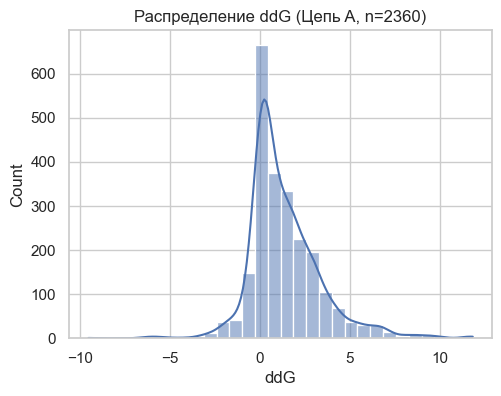

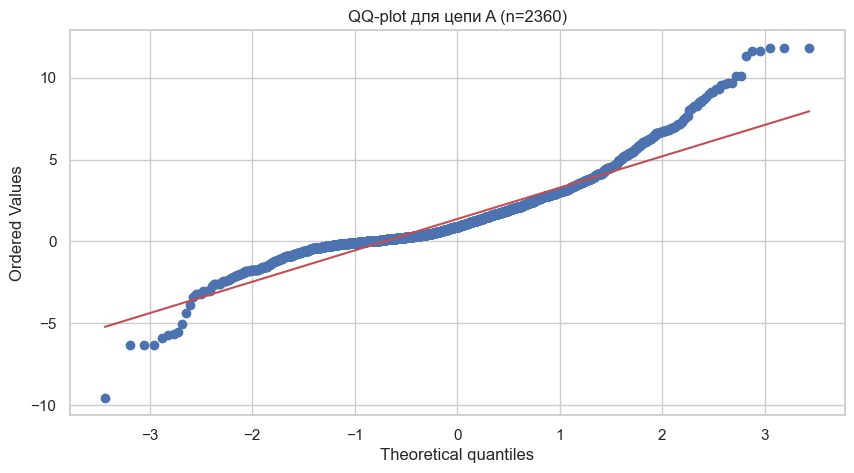

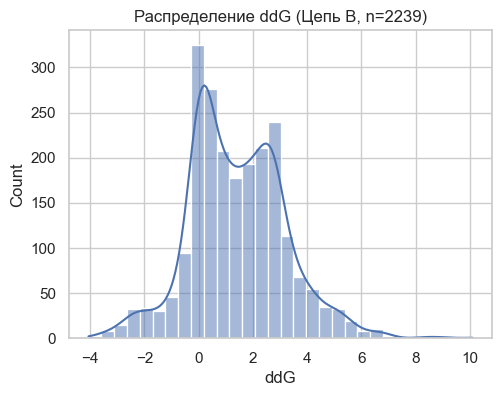

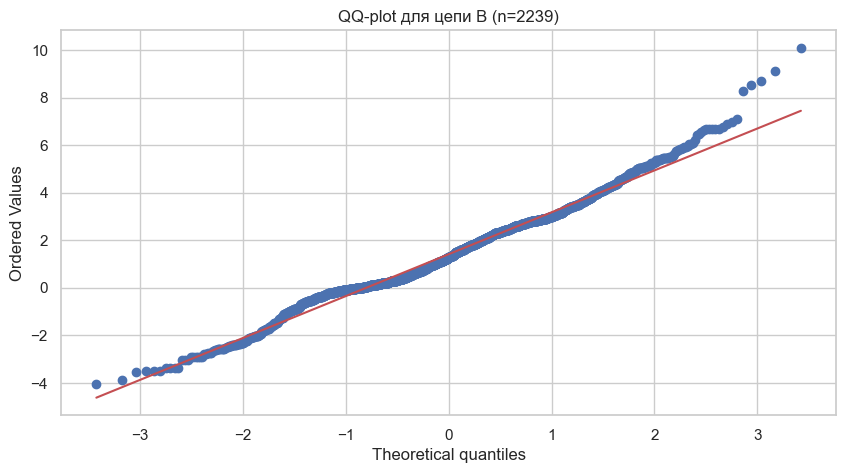

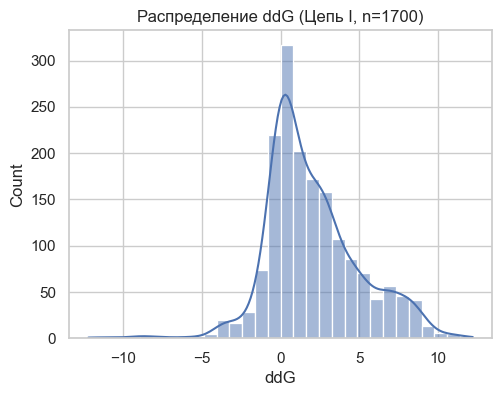

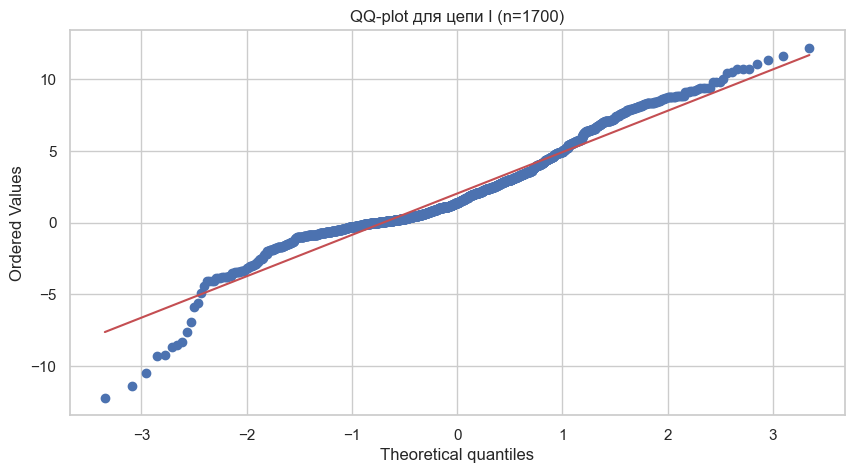

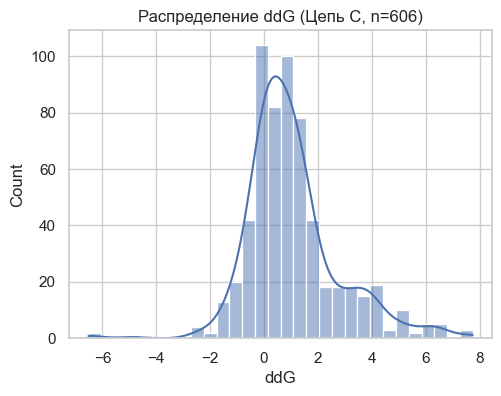

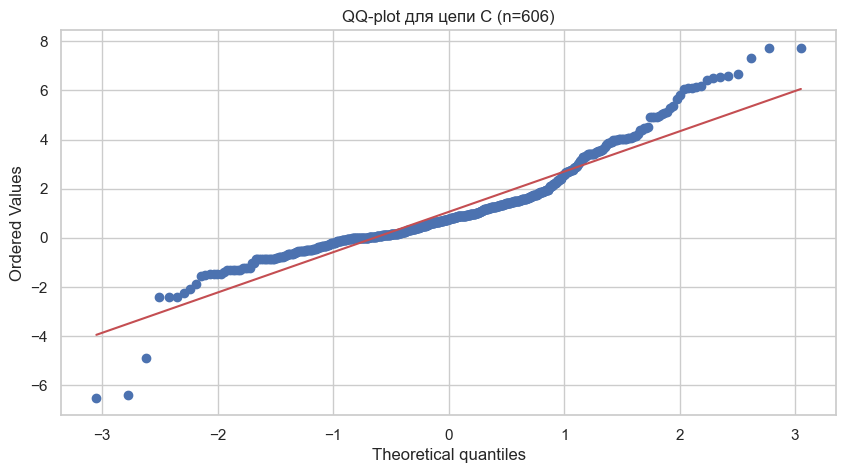

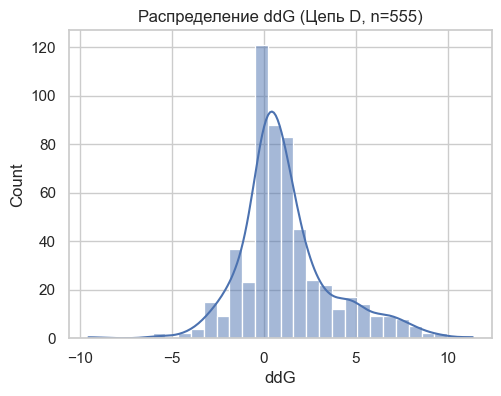

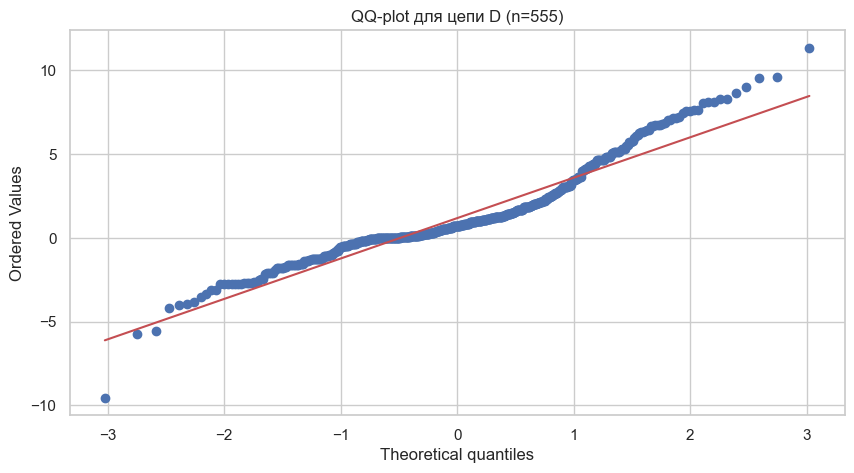

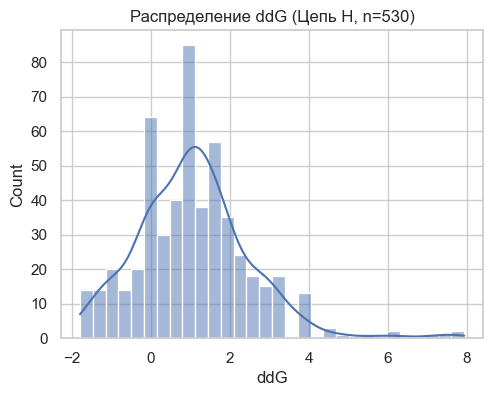

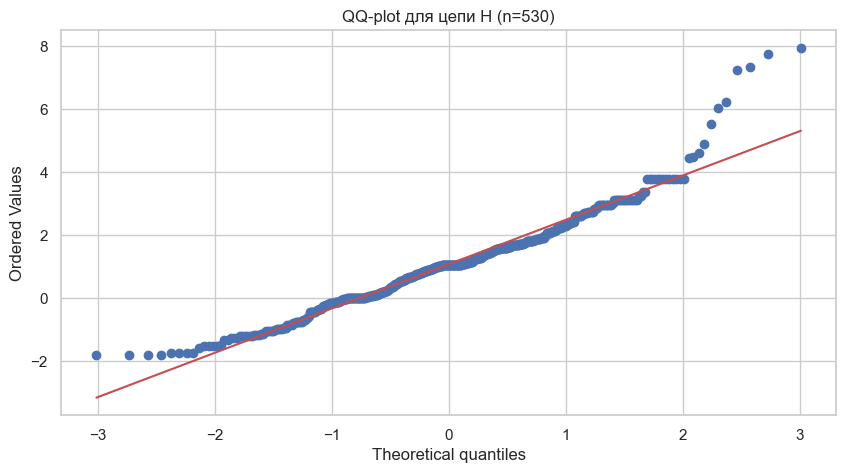

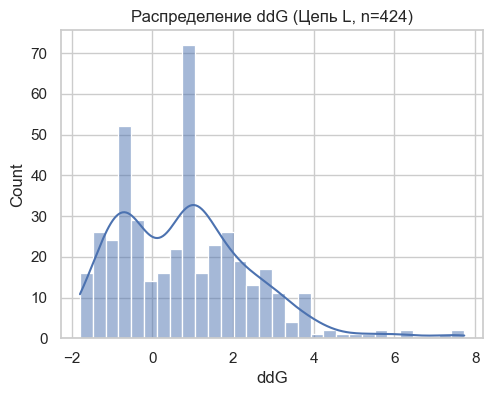

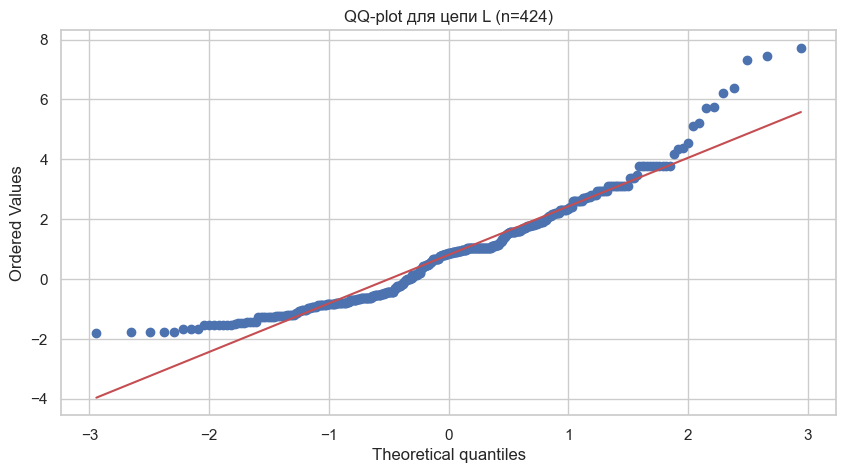

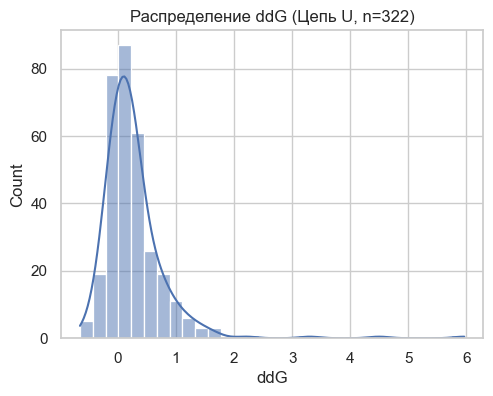

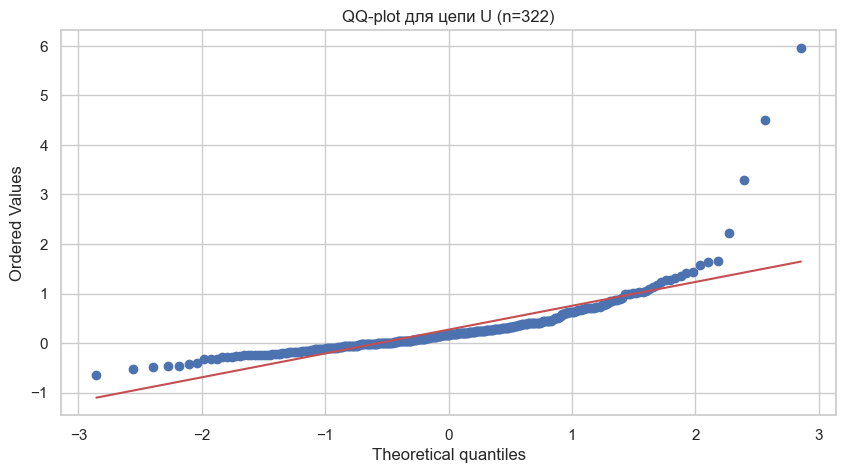

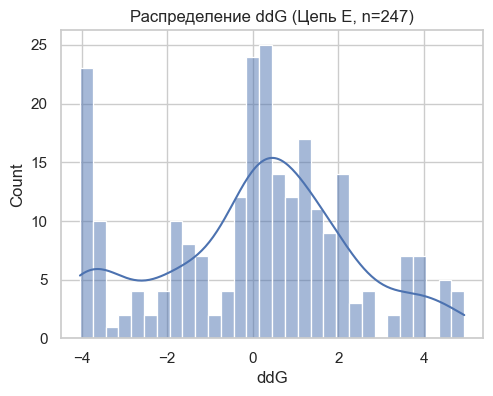

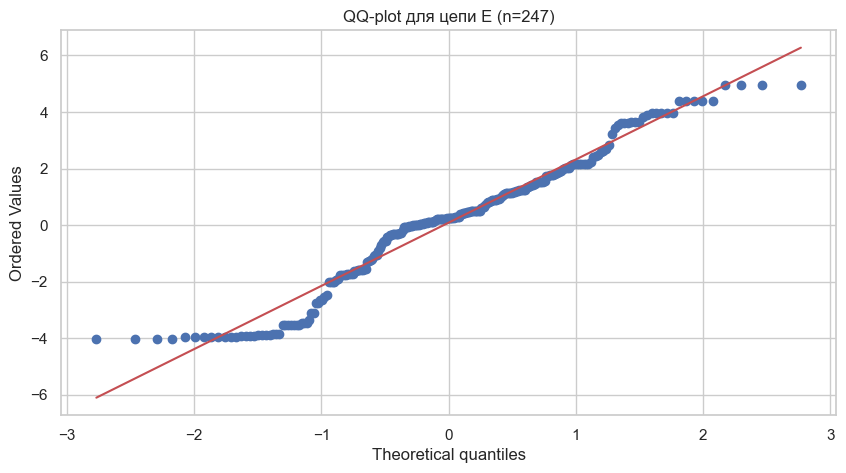

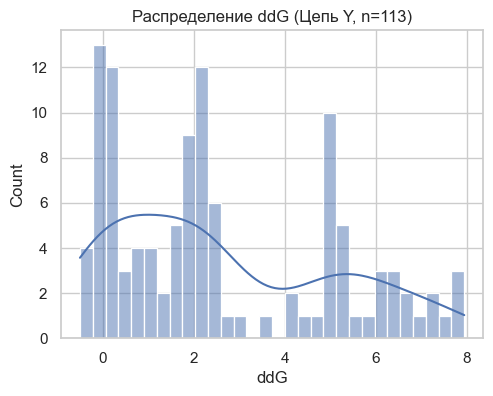

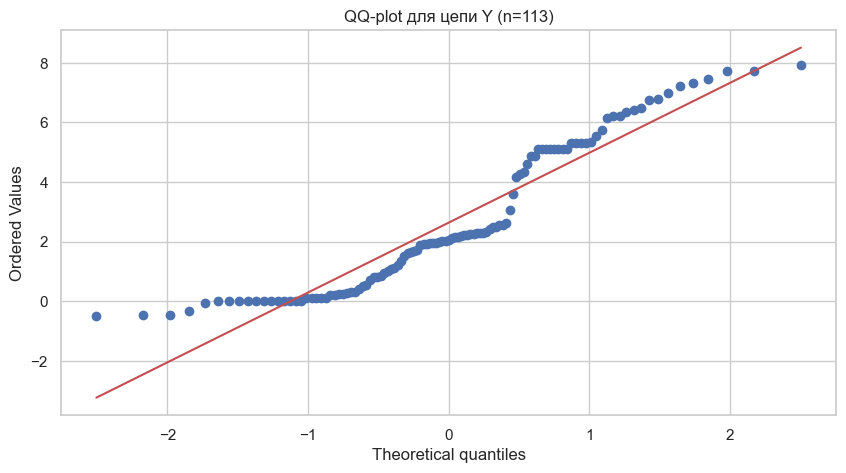

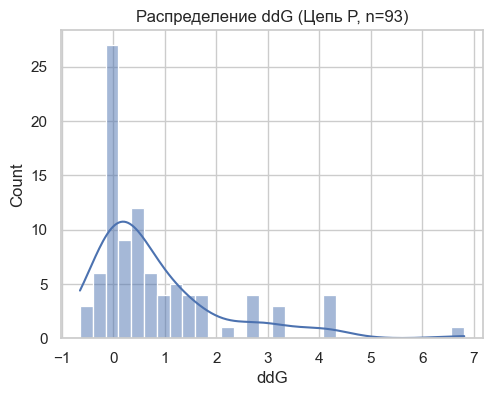

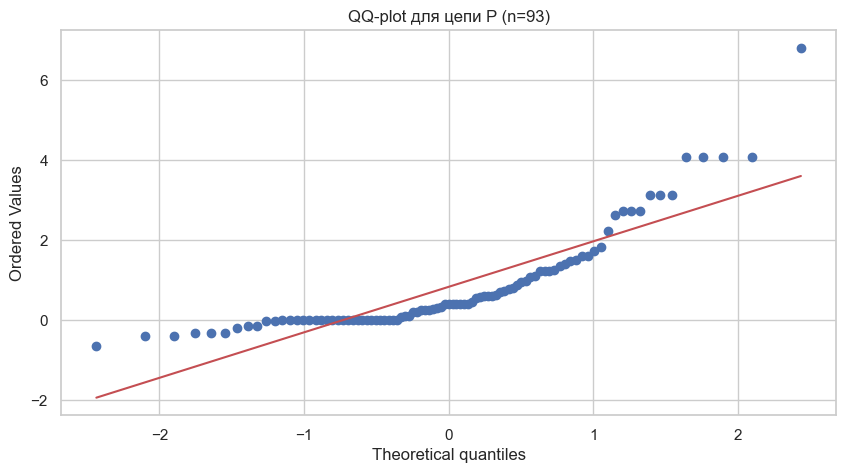

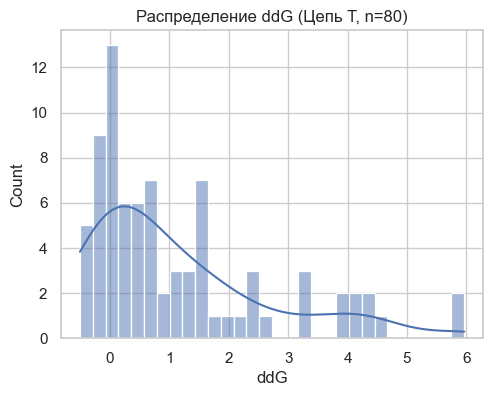

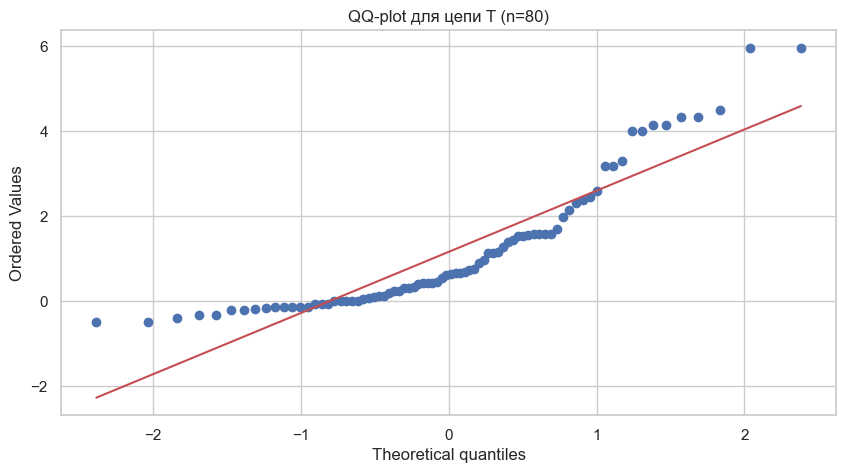

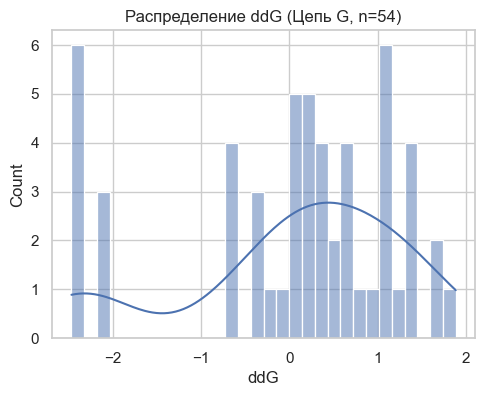

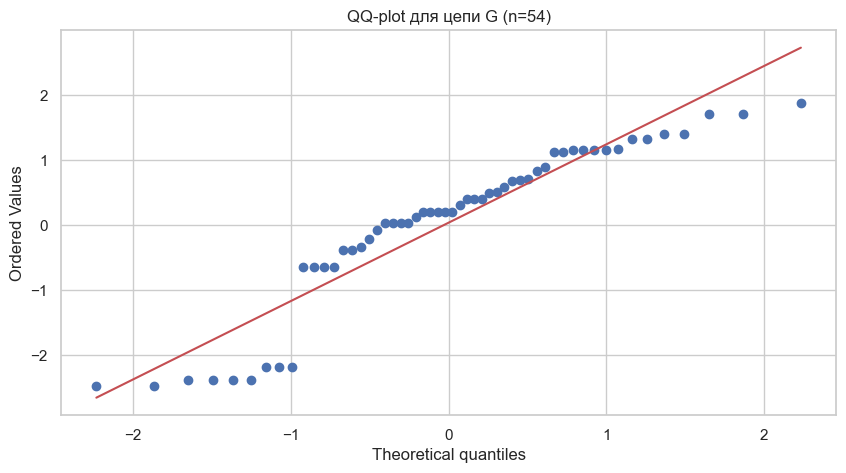

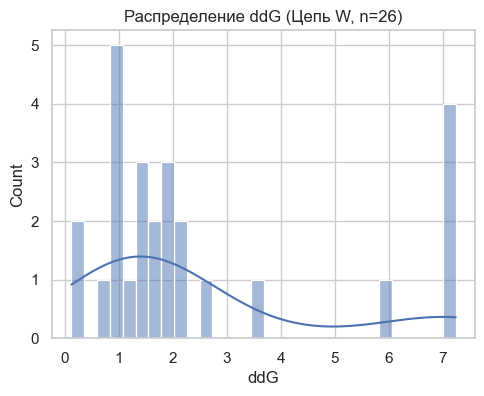

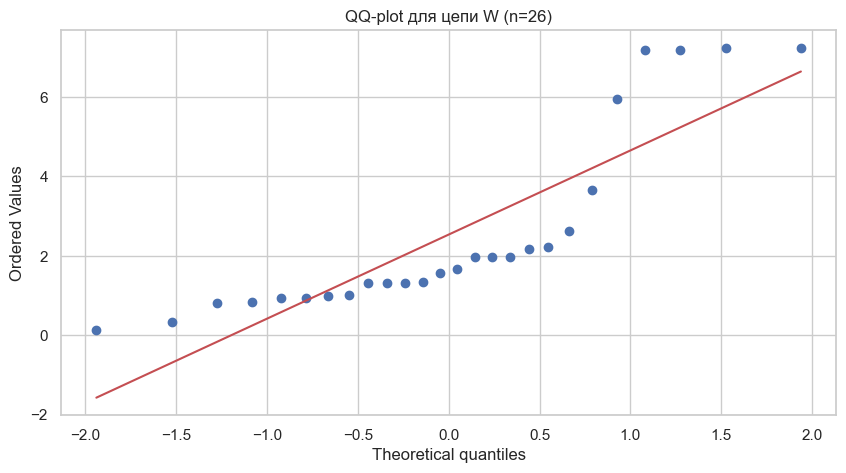

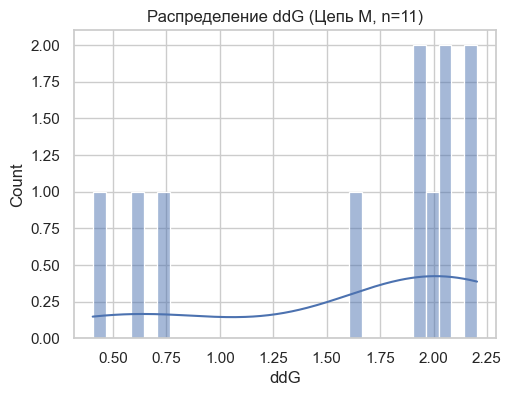

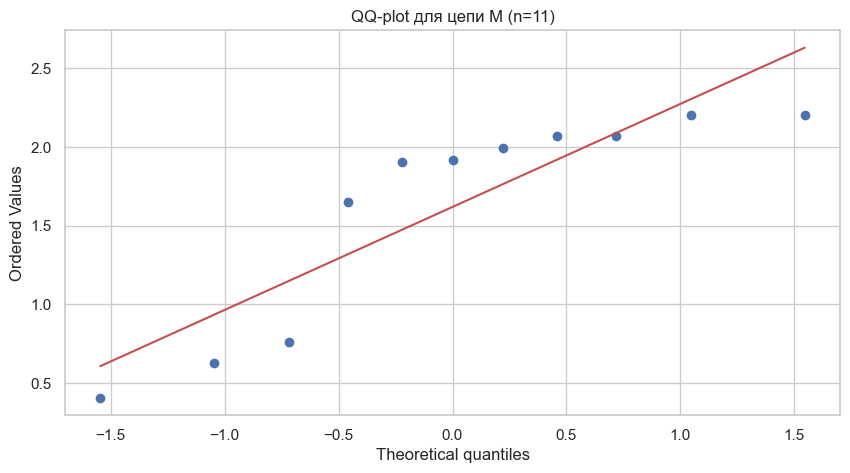

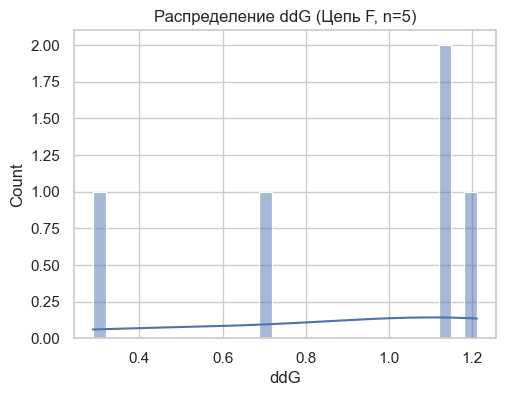

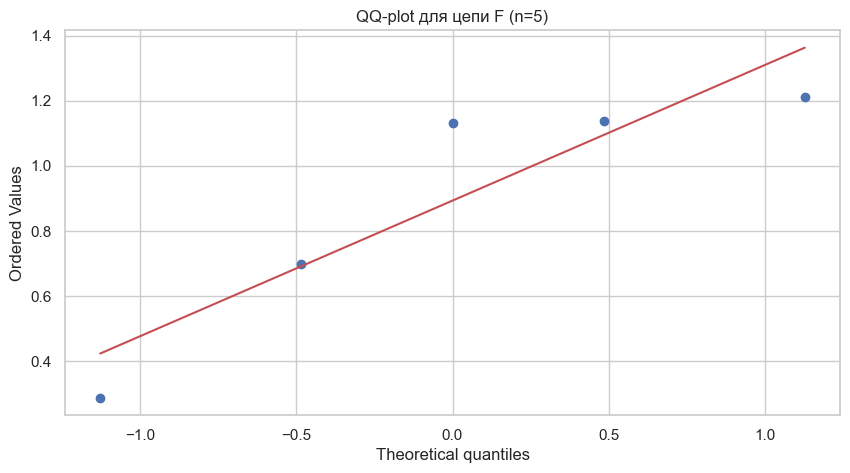

Результаты проверки нормальности:
chain  n_obs      p_value
    A   2360 3.477208e-36
    B   2239 1.752929e-14
    I   1700 2.351080e-23
    C    606 3.967023e-18
    D    555 9.900986e-16
    H    530 6.175171e-12
    L    424 9.813184e-12
    U    322 7.869382e-25
    E    247 4.109430e-06
    Y    113 3.932645e-07
    P     93 9.929846e-11
    T     80 5.779356e-08
    G     54 8.437881e-05
    W     26 2.914912e-05
    M     11 4.860209e-03
    F      5 1.495697e-01
    N      2          NaN
    Q      2          NaN


In [61]:
# 1. Подготовка данных
normality_results = []
for chain in df['chain'].unique():
    data = df[df['chain'] == chain]['ddG'].dropna()
    n_obs = len(data)  # Количество наблюдений в цепи
    if n_obs >= 3:
        _, p_val = stats.shapiro(data)
        normality_results.append({'chain': chain, 'n_obs': n_obs, 'p_value': p_val})
    else:
        normality_results.append({'chain': chain, 'n_obs': n_obs, 'p_value': np.nan})

normality_df = pd.DataFrame(normality_results).sort_values('n_obs', ascending=False)

# 2. График проверки нормальности (QQ-plot)
def plot_qq(chain, data):
    plt.figure(figsize=(10, 5))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'QQ-plot для цепи {chain} (n={len(data)})')
    plt.show()

# 3. Визуализация для цепей с достаточным количеством данных
for chain in normality_df[normality_df['n_obs'] >= 3]['chain']:
    data = df[df['chain'] == chain]['ddG'].dropna()
    
    # Гистограмма с распределением
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(data, kde=True, bins=30)
    plt.title(f'Распределение ddG (Цепь {chain}, n={len(data)})')
    
    # QQ-plot
    plot_qq(chain, data)

# 4. Вывод результатов проверки нормальности
print("Результаты проверки нормальности:")
print(normality_df.to_string(index=False))

**А вообще, для чего мы это всё делаем?**

Дело всё в том, что в рамках упрощения модели, я принял решение о **разбиении всех идентификаторов цепи на группы** (как мы это делали с методами, помните?) вместо того, чтобы кодировать абсолютно каждую группу и усложнять модель. Но чтобы разбить их на группы, нужно на что-то опираться, верно? В качестве этой «опоры» выбрал уровень влияния на целевую переменную. Есть смысл поделить все идентификаторы цепи на:
- ультра сильное влияние;
- очень сильное влияние;
- сильное влияние;
- среднее влиняие;
- слабое влияние;
- никакое.

**Опять же, разбиение происходит с опорой исключительно на статистические показатели различных тестов.**

Исходя из всех имеющихся у нас данных я могу сделать вывод о том, что проводить деление по тесту ANOVA (дисперсионному анализу) нецелесообразно по причине:
1) **крайне низких результатов теста Шапиро-Уилка,** которые дают нам право утверждать, что **данные рапределены ненормально** (если не брать во внимание одно единственное нормальное значение F). Результаты теста Андерсона-Дарлинга также частично подтверждают это;
2) **результат теста Левена на однородность дисперсий дал p-value = 1.114e-156**, что также указывает на **недопустимость предположения о равенстве дисперсий между группами.**

На основании этого, можно поробовать применить **Welch’s t-test (о равенстве математических ожиданий)**

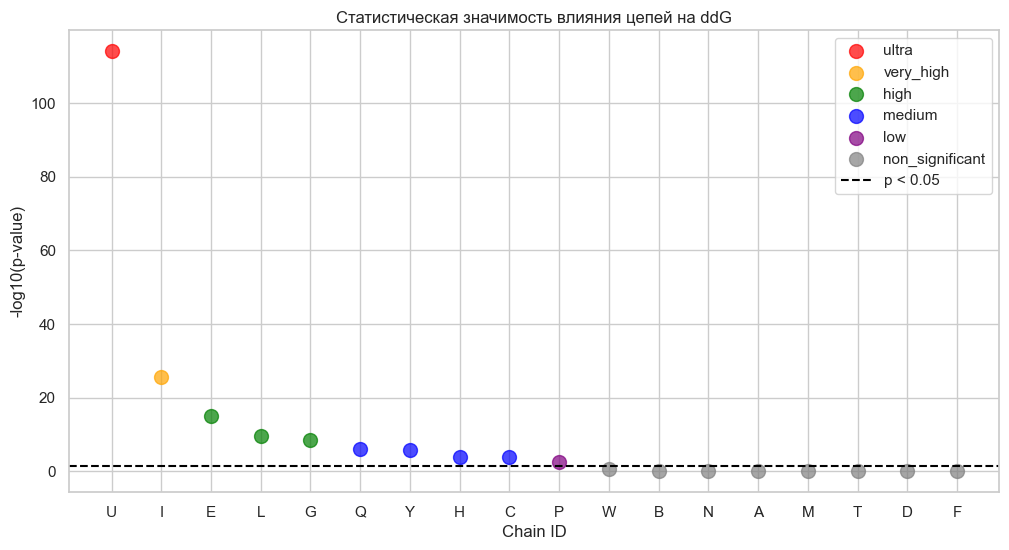

   chain  n_obs  mean_ddG  p_value_corrected     impact_group
6      U    322  0.273059      8.411686e-115            ultra
0      I   1700  2.034165       3.081071e-26        very_high
8      E    247  0.085589       1.004954e-15             high
11     L    424  0.804909       3.108454e-10             high
15     G     54  0.038857       3.616035e-09             high
14     Q      2  3.078630       9.608159e-07           medium
13     Y    113  2.638944       2.079640e-06           medium
9      H    530  1.073592       1.340008e-04           medium
4      C    606  1.051997       1.829767e-04           medium
7      P     93  0.829975       2.654806e-03              low
10     W     26  2.532836       2.883988e-01  non_significant
3      B   2239  1.410600       1.000000e+00  non_significant
5      N      2 -0.297862       1.000000e+00  non_significant
1      A   2360  1.366947       1.000000e+00  non_significant
16     M     11  1.619079       1.000000e+00  non_significant
12     T

In [63]:
from statsmodels.stats.multitest import multipletests

# Все уникальные цепи
all_chains = ['I', 'A', 'D', 'B', 'C', 'N', 'U', 'P', 'E', 'H', 'W', 'L', 'T', 'Y', 'Q', 'G', 'M', 'F']

# 1. Собираем статистику для каждой цепи
chain_stats = []
for chain in all_chains:
    if chain not in df['chain'].unique():
        continue
        
    current = df[df['chain'] == chain]['ddG'].dropna()
    others = df[df['chain'] != chain]['ddG'].dropna()
    n_obs = len(current)
    
    # Welch’s t-test (равенство дисперсий не предполагается)
    if n_obs >= 2:
        _, p_val = stats.ttest_ind(current, others, equal_var=False, nan_policy='omit')
    else:
        p_val = np.nan
    
    chain_stats.append({
        'chain': chain,
        'n_obs': n_obs,
        'mean_ddG': current.mean(),
        'p_value': p_val
    })

# 2. Создаем DataFrame и применяем поправку Бонферрони
chain_stats = pd.DataFrame(chain_stats)
chain_stats['p_value_corrected'] = multipletests(chain_stats['p_value'], method='bonferroni')[1]

# 3. Группировка по уровню значимости
bins = [-np.inf, 1e-30, 1e-15, 1e-7, 1e-3, 0.05, np.inf]
labels = ['ultra', 'very_high', 'high', 'medium', 'low', 'non_significant']
chain_stats['impact_group'] = pd.cut(
    chain_stats['p_value_corrected'],
    bins=bins,
    labels=labels,
    right=False
)

# 4. Сортировка по p-value
chain_stats = chain_stats.sort_values(by='p_value_corrected')

# 5. Визуализация
plt.figure(figsize=(12, 6))
colors = {'ultra': 'red', 'very_high': 'orange', 'high': 'green', 'medium': 'blue', 'low': 'purple', 'non_significant': 'gray'}

for group in labels:
    data = chain_stats[chain_stats['impact_group'] == group]
    plt.scatter(
        data['chain'], 
        -np.log10(data['p_value_corrected']), 
        label=group, 
        color=colors[group],
        s=100,
        alpha=0.7
    )

plt.axhline(-np.log10(0.05), color='black', linestyle='--', label='p < 0.05')
plt.xlabel('Chain ID')
plt.ylabel('-log10(p-value)')
plt.title('Статистическая значимость влияния цепей на ddG')
plt.legend()
plt.grid(True)
plt.show()

# 6. Вывод результатов
print(chain_stats[['chain', 'n_obs', 'mean_ddG', 'p_value_corrected', 'impact_group']])

Нетрудно заметить **экстремалное значение идентификатора цепи U,** которому система присвоила группу «ultra». Не думаю, что есть смысл удалить это значение. Можно поробовать провести более **консервативный тест Манна-Уитни** засчёт того, что он менее устойчив к экстремальным выбросам и менее чувствителен к нормальности распределения. 

In [65]:
def mannwhitney_test(chain):
    current = df[df['chain'] == chain]['ddG'].dropna()
    others = df[df['chain'] != chain]['ddG'].dropna()
    _, p_val = stats.mannwhitneyu(current, others, alternative='two-sided')
    return p_val

# Обновляем chain_stats с непараметрическими p-value
chain_stats['p_value_mw'] = chain_stats['chain'].apply(
    lambda x: mannwhitney_test(x) if x in df['chain'].unique() else np.nan
)

In [66]:
chain_stats['p_value_mw_corrected'] = multipletests(
    chain_stats['p_value_mw'], method='fdr_bh'
)[1]

In [67]:
print(chain_stats[['chain', 'p_value_corrected', 'p_value_mw_corrected']])

   chain  p_value_corrected  p_value_mw_corrected
6      U      8.411686e-115          5.340634e-32
0      I       3.081071e-26          2.716915e-21
8      E       1.004954e-15          1.763143e-13
11     L       3.108454e-10          2.415908e-08
15     G       3.616035e-09          1.368748e-05
14     Q       9.608159e-07          1.484828e-01
13     Y       2.079640e-06          2.657471e-07
9      H       1.340008e-04          1.777065e-01
4      C       1.829767e-04          1.248375e-03
7      P       2.654806e-03          6.828958e-03
10     W       2.883988e-01          6.813520e-03
3      B       1.000000e+00          2.415908e-08
5      N       1.000000e+00          1.484828e-01
1      A       1.000000e+00          4.591163e-01
16     M       1.000000e+00          2.018719e-01
12     T       1.000000e+00          3.245891e-01
2      D       1.000000e+00          1.353733e-03
17     F       1.000000e+00          9.375142e-01


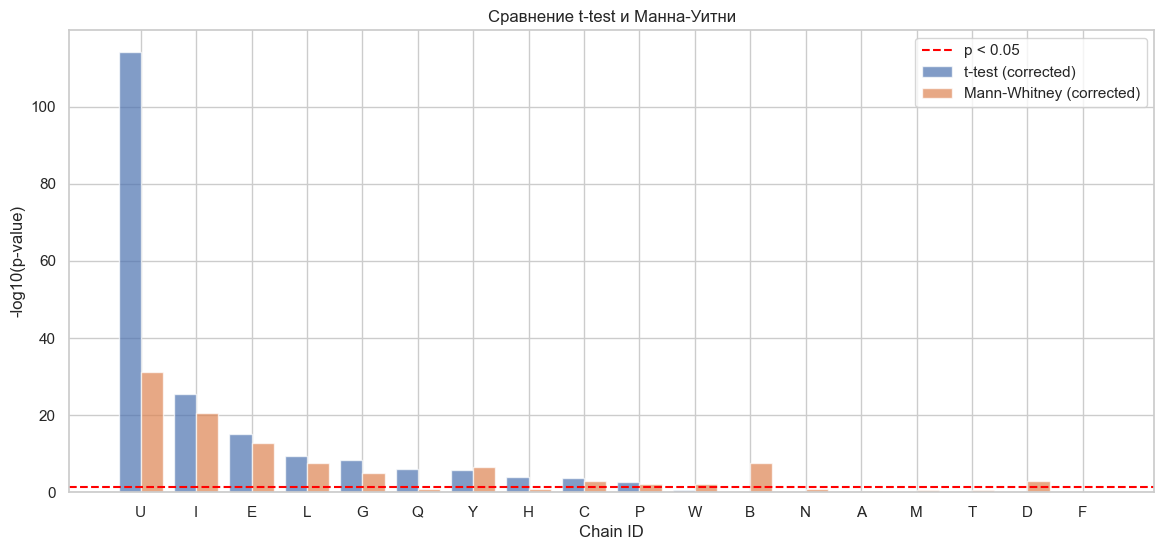

In [68]:
# Для наглядности выведем график сравнения p-value результатов t-test и Манна-Уитни

plt.figure(figsize=(14, 6))
x = np.arange(len(chain_stats))

# t-test p-values
plt.bar(x - 0.2, -np.log10(chain_stats['p_value_corrected']), width=0.4, label='t-test (corrected)', alpha=0.7)

# Mann-Whitney p-values
plt.bar(x + 0.2, -np.log10(chain_stats['p_value_mw_corrected']), width=0.4, label='Mann-Whitney (corrected)', alpha=0.7)

plt.xticks(x, chain_stats['chain'])
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p < 0.05')
plt.xlabel('Chain ID')
plt.ylabel('-log10(p-value)')
plt.title('Сравнение t-test и Манна-Уитни')
plt.legend()
plt.grid(True)
plt.show()

На основании полученных результатов я считаю проведение группировки на основании результатов теста Манна-Уитни наиболее привлекательной

In [70]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# 1. Считаем p-value Манна-Уитни для каждой цепи
chain_stats = []
for chain in df['chain'].unique():
    current = df[df['chain'] == chain]['ddG'].dropna()
    others = df[df['chain'] != chain]['ddG'].dropna()
    
    if len(current) >= 2:
        _, p_val = mannwhitneyu(current, others, alternative='two-sided')
    else:
        p_val = np.nan
    
    chain_stats.append({
        'chain': chain,
        'n_obs': len(current),
        'median_ddG': current.median(),  # Используем медиану вместо среднего!
        'p_value_mw': p_val
    })

chain_stats = pd.DataFrame(chain_stats)

# 2. Поправка на множественные сравнения (FDR)
chain_stats['p_value_mw_corrected'] = multipletests(
    chain_stats['p_value_mw'], method='fdr_bh'
)[1]

# 3. Группировка по уровню значимости
bins = [0, 1e-30, 1e-15, 1e-7, 1e-3, 0.05, np.inf]
labels = ['ultra', 'very_high', 'high', 'medium', 'low', 'non_significant']
chain_stats['impact_group'] = pd.cut(
    chain_stats['p_value_mw_corrected'],
    bins=bins,
    labels=labels,
    right=False
)

# 4. Сортировка по p-value
chain_stats = chain_stats.sort_values(by='p_value_mw_corrected')

# Вывод результатов
print(chain_stats[['chain', 'n_obs', 'median_ddG', 'p_value_mw_corrected', 'impact_group']])

   chain  n_obs  median_ddG  p_value_mw_corrected     impact_group
6      U    322    0.173780          5.340634e-32            ultra
0      I   1700    1.383044          2.716915e-21        very_high
8      E    247    0.259502          1.763143e-13             high
3      B   2239    1.285303          2.415908e-08             high
11     L    424    0.857267          2.415908e-08             high
13     Y    113    2.049680          2.657471e-07           medium
15     G     54    0.203171          1.368748e-05           medium
4      C    606    0.761213          1.248375e-03              low
2      D    555    0.711844          1.353733e-03              low
10     W     26    1.614663          6.813520e-03              low
7      P     93    0.410430          6.828958e-03              low
5      N      2   -0.297862          1.484828e-01  non_significant
14     Q      2    3.078630          1.484828e-01  non_significant
9      H    530    1.043107          1.777065e-01  non_signifi

После проведения группировки есть смысл посмотреть в принципе на распределение данных.

Вызвав подсчёт значений и визуализацию, нетрудно заметить явный дисбаланс классов:

| Группы цепей             | Количество |
|:-------------------:|:-----------:|
| chain_ultra           | **322**      |
|  chain_very_high           | 1700      |
| chain_high     | 2910     |
| chain_medium     | **167**      |
| chain_low     | 1280      |
| chain_non_significant    | 2990      |

Да, это не самое приятное, что хотелось бы увидеть на данном этапе работы, но, тем не менее продолжаем работать. На мой взгляд, будет вполне логично объединить некоторые группы по принципу:
- chain_ultra + chain_very_high = **chain_high_impact**;
- chain_medium + chain_low = **chain_medium_low**.

Всё остальное остаётся без изменений

In [72]:
# Проходимся циклом для применения изменений к датасету

for group in labels:
    chains_in_group = chain_stats[chain_stats['impact_group'] == group]['chain'].tolist()
    df[f'chain_{group}'] = df['chain'].isin(chains_in_group).astype(int)

# Вызываем таблицу распределения

print("\nКоличество мутаций по группам:")
print(df[[f'chain_{group}' for group in labels]].sum())


Количество мутаций по группам:
chain_ultra               322
chain_very_high          1700
chain_high               2910
chain_medium              167
chain_low                1280
chain_non_significant    2990
dtype: int64


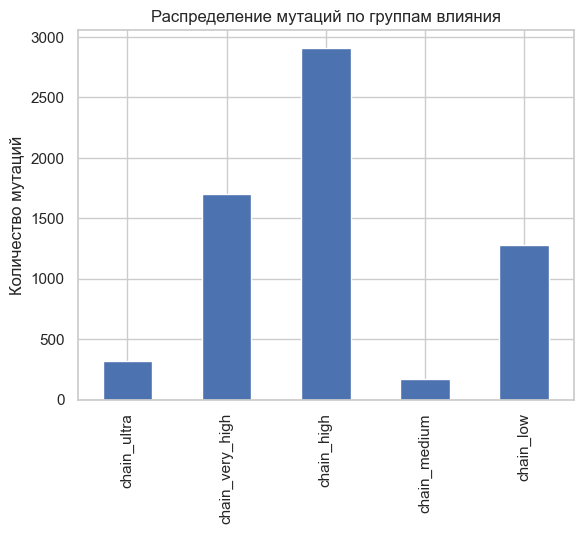

In [73]:
# То же самое, но в виде графика

df[['chain_ultra', 'chain_very_high', 'chain_high', 
    'chain_medium', 'chain_low']].sum().plot(kind='bar')
plt.title('Распределение мутаций по группам влияния')
plt.ylabel('Количество мутаций')
plt.show()

In [74]:
# Объединяем группы, согласно описанию (выше)

df['chain_high_impact'] = (df['chain_ultra'] | df['chain_very_high']).astype(int)
df['chain_medium_low'] = (df['chain_medium'] | df['chain_low']).astype(int)

# И удаляем исходные колонки

df.drop(['chain_ultra', 'chain_very_high', 'chain_medium', 'chain_low'], axis=1, inplace=True)

И в конечном итоге получаем вполне себе «относительно неплохое» распределение данных

In [76]:
# Вызываем уже знакому. нам таблицу распределения

print(df[['chain_high_impact', 'chain_high', 'chain_medium_low', 'chain_non_significant']].sum())

chain_high_impact        2022
chain_high               2910
chain_medium_low         1447
chain_non_significant    2990
dtype: int64


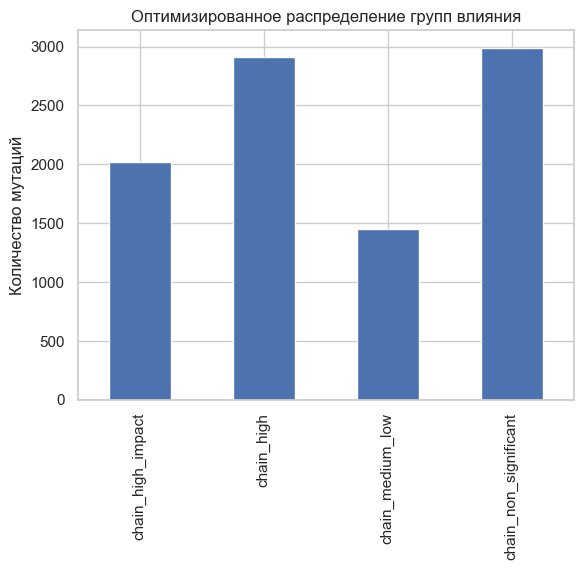

In [77]:
# То же самое, но в виде графика

df[['chain_high_impact', 'chain_high', 'chain_medium_low', 'chain_non_significant']].sum().plot(kind='bar')
plt.title('Оптимизированное распределение групп влияния')
plt.ylabel('Количество мутаций')
plt.show()

In [78]:
# Удалим колонку chain за ненадобностью и некоторые «артефактные колонки», оставшиеся от прошлых шагов

columns_to_drop = ['chain','is_multiple_mutation','Mutation(s)_cleaned']
df = df.drop(columns = columns_to_drop, errors='ignore')

# Смотрим датасет и да, они появились

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9369 entries, 0 to 9368
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Affinity_mut_parsed    9369 non-null   float64
 1   Affinity_wt_parsed     9369 non-null   float64
 2   Temperature            9369 non-null   float64
 3   ddG                    9369 non-null   float64
 4   count_COR              9369 non-null   int64  
 5   count_SUP              9369 non-null   int64  
 6   count_RIM              9369 non-null   int64  
 7   count_INT              9369 non-null   int64  
 8   count_SUR              9369 non-null   int64  
 9   SPR_group              9369 non-null   int64  
 10  Fluorescence           9369 non-null   int64  
 11  Other_methods          9369 non-null   int64  
 12  n_mutations            9369 non-null   int64  
 13  orig_aa                9369 non-null   object 
 14  pos                    9369 non-null   int64  
 15  mut_

#### 3.2.3.4 Последние штрихи

Для завершения работы с данными нам **осталось заменить все значения аминокислот**, представленные в датасете текстовым форматом в виде одной буквы, **на числовые значения гидрофобности и молекулярной массы**, а также **закодировать целевую перемнную в значения -1, 0 и 1**, ведь в о рамках задания нам нужно определить знак свободной энергии связывания ddG, а не само её значение.

In [81]:
# Создаём словарь свойств аминокислот (гидрофобность и молекулярная масса)

aa_properties = {
    'A': {'hyd': 1.8,  'mw': 89.09},    # Alanine
    'R': {'hyd': -4.5, 'mw': 174.20},   # Arginine
    'N': {'hyd': -3.5, 'mw': 132.12},   # Asparagine
    'D': {'hyd': -3.5, 'mw': 133.10},   # Aspartic acid
    'C': {'hyd': 2.5,  'mw': 121.15},   # Cysteine
    'E': {'hyd': -3.5, 'mw': 147.13},   # Glutamic acid
    'Q': {'hyd': -3.5, 'mw': 146.15},   # Glutamine
    'G': {'hyd': -0.4, 'mw': 75.07},    # Glycine
    'H': {'hyd': -3.2, 'mw': 155.16},   # Histidine
    'I': {'hyd': 4.5,  'mw': 131.17},   # Isoleucine
    'L': {'hyd': 3.8,  'mw': 131.17},   # Leucine
    'K': {'hyd': -3.9, 'mw': 146.19},   # Lysine
    'M': {'hyd': 1.9,  'mw': 149.21},   # Methionine
    'F': {'hyd': 2.8,  'mw': 165.19},   # Phenylalanine
    'P': {'hyd': -1.6, 'mw': 115.13},   # Proline
    'S': {'hyd': -0.8, 'mw': 105.09},   # Serine
    'T': {'hyd': -0.7, 'mw': 119.12},   # Threonine
    'W': {'hyd': -0.9, 'mw': 204.23},   # Tryptophan
    'Y': {'hyd': -1.3, 'mw': 181.19},   # Tyrosine
    'V': {'hyd': 4.2,  'mw': 117.15}    # Valine
}

# Добавляем колонки со свойствами

df['orig_hyd'] = df['orig_aa'].map(lambda x: aa_properties.get(x, {}).get('hyd', 0))
df['orig_mw'] = df['orig_aa'].map(lambda x: aa_properties.get(x, {}).get('mw', 0))
df['mut_hyd'] = df['mut_aa'].map(lambda x: aa_properties.get(x, {}).get('hyd', 0))
df['mut_mw'] = df['mut_aa'].map(lambda x: aa_properties.get(x, {}).get('mw', 0))

# Удаляем колонки уже ненужные нам колонки с буквенными обозначениями

df = df.drop(columns=['orig_aa', 'mut_aa'])

# От греха подальше вызываем первые пять строк датасета

print("Новые колонки в датафрейме:")
print(df[['orig_hyd', 'orig_mw', 'mut_hyd', 'mut_mw']].head())

Новые колонки в датафрейме:
   orig_hyd  orig_mw  mut_hyd  mut_mw
0       3.8   131.17     -0.4   75.07
1       3.8   131.17     -0.8  105.09
2       3.8   131.17     -1.6  115.13
3       3.8   131.17      4.5  131.17
4       3.8   131.17     -3.5  133.10


In [82]:
# Преобразуем целевую переменную в target

df['target'] = np.where(df['ddG'] > 0, 1, np.where(df['ddG'] < 0, -1, 0))

# Заодно поверим распределения классов

print("Распределение классов:")
print(df['target'].value_counts())

# Удалим исходную колонку ddG

df = df.drop(columns=['ddG'])

# Выделим признаки и целевую переменную

X = df.drop(columns=['target']) 
y = df['target']

# Лишний раз убедимся, что все сделано правильно

print("\nФинальные признаки:")
print(X.columns.tolist())

Распределение классов:
 1    7143
-1    2019
 0     207
Name: target, dtype: int64

Финальные признаки:
['Affinity_mut_parsed', 'Affinity_wt_parsed', 'Temperature', 'count_COR', 'count_SUP', 'count_RIM', 'count_INT', 'count_SUR', 'SPR_group', 'Fluorescence', 'Other_methods', 'n_mutations', 'pos', 'chain_high', 'chain_non_significant', 'chain_high_impact', 'chain_medium_low', 'orig_hyd', 'orig_mw', 'mut_hyd', 'mut_mw']


**Пара слов напоследок**

Смотря на финальное распределение классов целевой перемнной, становится понятно почему наши предки придумали поговорку: «В бочке мёда, ложка дёгтя». Не самое приятное, что хотелось бы видеть перед обучением модели - виден явный **дисбаланс классов.** В таком случае не отчаиваемся и работаем дальше, не всем же данным быть «идеальными».

# 4. Обучение модели

## 4.1 Неприятности не закончились или тест на мультиколлинеарность

Перед обучением модели неплохо было бы провести **тест на мультиколлинеарность,** т.е., грубо говоря, ответить на вопрос: «зависят ли одни признаки от других?»

Для этого «по старинке» вызовем **тепловую матрицу корреляции** и посмотрим на её результаты (а также у себя в уме держим порог мультиколлинеарности в, ориентировочно, 0.8).

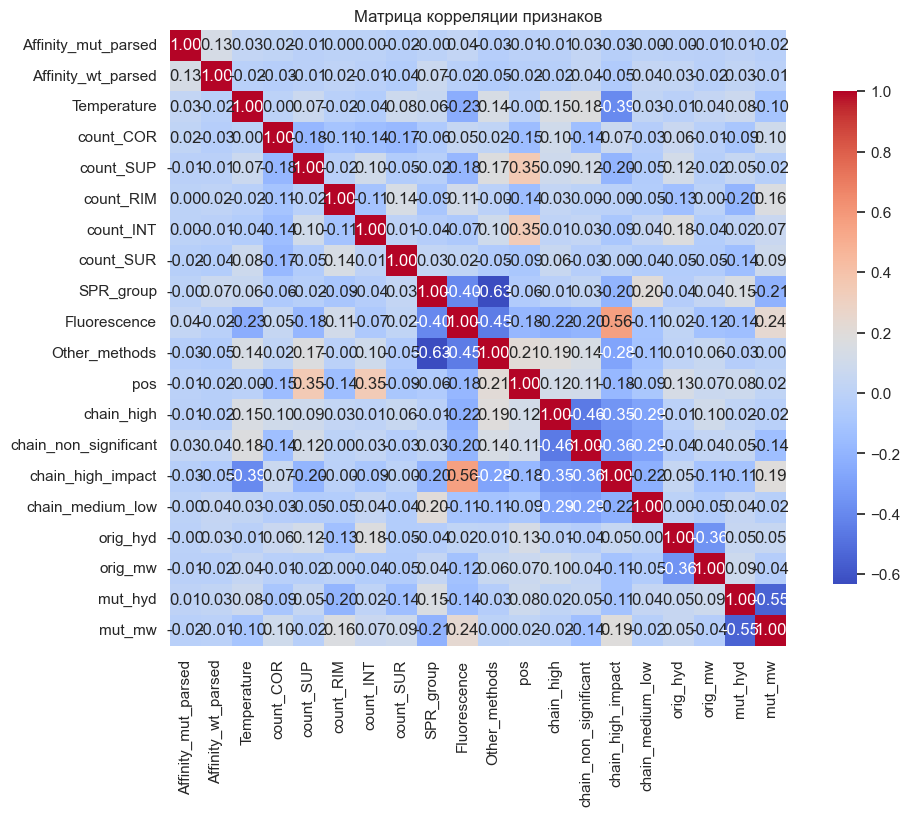

In [87]:
# Сперва определим основные признаки

features = [
    'Affinity_mut_parsed', 'Affinity_wt_parsed', 'Temperature', 
    'count_COR', 'count_SUP', 'count_RIM', 'count_INT', 'count_SUR',
    'SPR_group', 'Fluorescence', 'Other_methods', 'pos',
    'chain_high', 'chain_non_significant', 'chain_high_impact',
    'chain_medium_low', 'orig_hyd', 'orig_mw', 'mut_hyd', 'mut_mw'
]

# Выберем их

X = df[features]

# Вычислим матрицу корреляций

correlation_matrix = X.corr()

# Вызываем тепловую матрицу корреляций

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляции признаков')
plt.show()

Некоторые значения корреляций мне показались лостаточно «сомнительными», я имею ввиду значения 0.48, 0.50 и 0.56. Насколько я знаю, знаечния корреляций, лежащие в пределах от 0.4 до 0.6 считается «умеренной или средней», что не совсем хорошо. Мне показались результаты матрицы не совсем убедительными, поэтому для более детального исследования мультиколлинеарных зависмостей, на мой взгляд, будет лучще обратиться к **VIF (измеряет количество завышенных дисперсий, вызванных мультиколлинеарностью).**

In [89]:
# ыведем все значения VIF и создадим для него датафрейм

X_vif = X[features]

# Вычислим VIF для каждого признака

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                  Feature          VIF
0     Affinity_mut_parsed     1.025861
1      Affinity_wt_parsed     1.036259
2             Temperature     1.227010
3               count_COR     1.186458
4               count_SUP     1.225867
5               count_RIM     1.144028
6               count_INT     1.204534
7               count_SUR     1.114496
8               SPR_group   181.898153
9            Fluorescence   137.324512
10          Other_methods   191.575933
11                    pos     1.407022
12             chain_high  2228.548209
13  chain_non_significant  2293.976616
14      chain_high_impact  1512.405584
15       chain_medium_low  1104.322691
16               orig_hyd     1.253697
17                orig_mw     1.205762
18                mut_hyd     1.525544
19                 mut_mw     1.581663


**Все признаки со значением больше 10 и inf (бесконечность) удаляются.**

In [91]:
# выбираем признаки с бесконечным и непомерно высоким VIF

high_vif_features = [
    'count_COR', 'count_SUP', 'count_RIM', 'count_INT', 'count_SUR', 
    'SPR_group', 'Fluorescence', 'Other_methods', 'chain_high',
    'chain_non_significant', 'chain_high_impact', 'chain_medium_low', 'mut_mw'
]

# И удаляем их

X_filtered = X.drop(columns=high_vif_features)

Смотрим также, что стало после удаления проблемных признаков и замечаем, что ничего хорошего. **Признаки Temperature и orig_mw увеличили свои значения.** Удалим их тоже.

In [93]:
# И смотрим, что стало после удаления проблемных признаков

from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

vif_result = calculate_vif(X_filtered)
print("VIF после удаления проблемных признаков:")
print(vif_result.sort_values("VIF", ascending=False))

VIF после удаления проблемных признаков:
               Feature        VIF
5              orig_mw  27.824109
2          Temperature  25.677529
4             orig_hyd   1.408721
3                  pos   1.336488
6              mut_hyd   1.037371
1   Affinity_wt_parsed   1.031710
0  Affinity_mut_parsed   1.021800


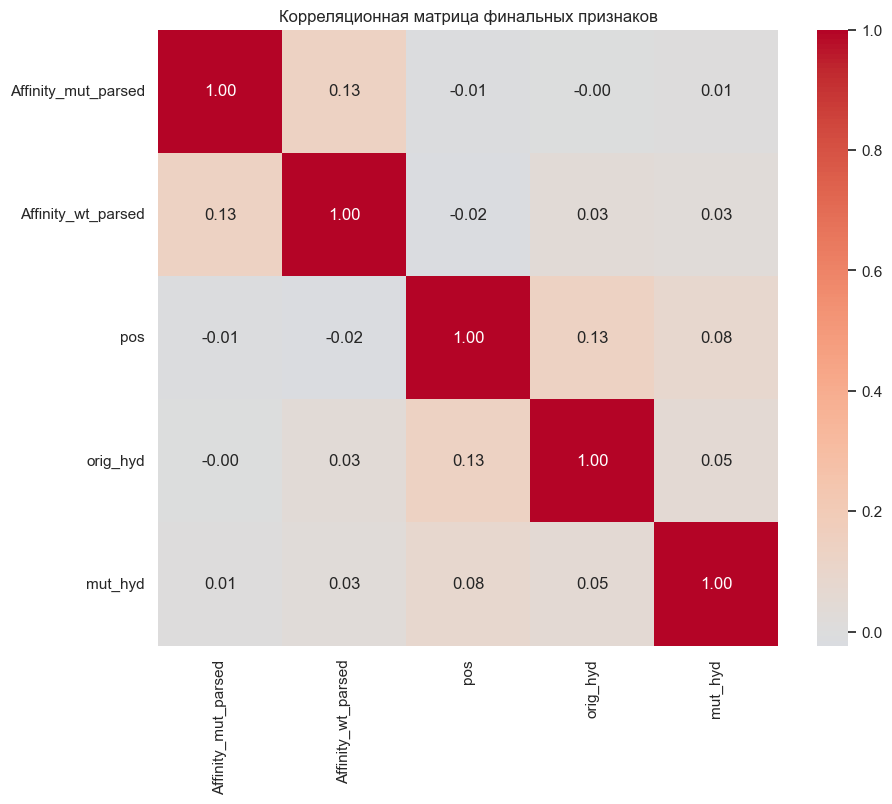

In [94]:
# Оставляем подходящие признаки

acceptable_features = ['Affinity_mut_parsed', 'Affinity_wt_parsed',
    'pos','orig_hyd','mut_hyd']

X_final = X[acceptable_features]

# И выводим уже окончательную тепловую матрицу

plt.figure(figsize=(10, 8))
corr_matrix = X_final.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Корреляционная матрица финальных признаков')
plt.show()

## 4.2 Обучение модели

Вот и настало время обучать саму модель. Для нашей задачи вполне себе подойдут модели Random Forest и Gradient Boosting. Чисто ради примера сравнения можем вызвать также модель логистической регресиии (хотя я уже знаю, что она отработает хуже всех). Пока воспользуемся «стандартными» значениями:
- test_size = 0.2 (т.е. деление данных на обучающую (80%) и тестовую (20%) выборки);

In [97]:
# Загрузим данные

features = ['Affinity_mut_parsed', 'Affinity_wt_parsed', 'pos', 'orig_hyd', 'mut_hyd']
X = df[features]
y = df['target'].astype(str)  # Преобразуем метки в строки

# Разделим их

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Напишем функцию автоматического рассчёта семплирования (т.к. мы помним, что у нас жёсткий дисбаланс)

def calculate_sampling_strategy(y, multiplier=1.5):
    counts = Counter(y)
    strategy = {}
    for cls, count in counts.items():
        new_count = min(int(count * multiplier), count + 500)
        strategy[cls] = new_count
    return strategy

sampling_strategy = calculate_sampling_strategy(y_train)

# Определим модели (зададим и стандартные параметры)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        C=0.1,
        solver='saga',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
}

# Создадим пайплайн и начнём обучерие моделей

results = {}
for name, model in models.items():
    try:
        # Создаем пайплайн
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('sampler', SMOTE(
                sampling_strategy=sampling_strategy,
                k_neighbors=min(3, min(Counter(y_train).values())),
            )),
            ('classifier', model)
        ])

        # Само обучение
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        results[name] = {
            'report': classification_report(y_test, y_pred, output_dict=True),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred)
        }
        
        # Выведем результаты
        
        print(f"\n{name} Performance:")
        print(classification_report(y_test, y_pred))
        print(f"Balanced Accuracy: {results[name]['balanced_accuracy']:.3f}")
    
    except ValueError as e:
        print(f"\nОшибка в модели {name}: {str(e)}")
        # Используем версию без SMOTE при ошибках
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', model)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        results[name] = {
            'report': classification_report(y_test, y_pred, output_dict=True),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred)
        }


Random Forest Performance:
              precision    recall  f1-score   support

          -1       0.66      0.90      0.76       404
           0       0.44      0.68      0.54        41
           1       0.98      0.86      0.92      1429

    accuracy                           0.87      1874
   macro avg       0.69      0.82      0.74      1874
weighted avg       0.90      0.87      0.87      1874

Balanced Accuracy: 0.816

Gradient Boosting Performance:
              precision    recall  f1-score   support

          -1       0.90      0.72      0.80       404
           0       0.90      0.46      0.61        41
           1       0.92      0.98      0.95      1429

    accuracy                           0.91      1874
   macro avg       0.91      0.72      0.79      1874
weighted avg       0.91      0.91      0.91      1874

Balanced Accuracy: 0.722

Logistic Regression Performance:
              precision    recall  f1-score   support

          -1       0.31      0.41      

Можно обратить внимание, что **Random Forest,** как и ожидалось, **показала наилучшие результаты по Balanced Accuracy: 0.818.** Однако, согласно метрике f1-score, значения для 0 модель «угадывает», что не есть хорошо. Есть смысл увеличить вес классса для 0, чтобы немного повысить предсказания для этого класса. На этот раз оставим одну модель Random Forest и немного переработаем старый код

In [99]:
# Загрузим данные

features = ['Affinity_mut_parsed', 'Affinity_wt_parsed', 'pos', 'orig_hyd', 'mut_hyd']
X = df[features]
y = df['target'].astype(str)

# Разделим их

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Зададим оптимизированный пайплайн с ручным подбором гиперпараметров

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', SMOTE(
        sampling_strategy={'-1': 2000, '0': 600, '1': 5714},
        k_neighbors=3,
        random_state=42
    )),
    ('classifier', RandomForestClassifier(
        class_weight={'0': 3, '-1': 1, '1': 1},
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    'classifier__n_estimators': [300, 500],
    'classifier__max_depth': [5, 8, None],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [1, 3]
}

# Зададим оптимизацию по F1-weighted

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Выведем финальные результаты

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nBalanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1-score (класс 0):", f1_score(y_test, y_pred, labels=['0'], average=None)[0])

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Balanced Accuracy: 0.8129538700170517
F1-score (класс 0): 0.611764705882353
